# Credit Card Fraud Detection

---

| | |
|---|---|
| **Name** | Giorgio |
| **Surname** | Zoccatelli |
| **Student ID** | s349395 |
| **Exam** | Geometric Learning, Time-Variant Data analysis, and Anomaly Detection   |
| **Course** | MSc Data Science & Engineering, *Politecnico di Torino* |
| **Dataset** | Credit Card Transactions Fraud Detection (Kaggle) |
| **Academic Year** | 2026/27 |

---

## Abstract

Credit card fraud detection is an inherently asymmetric problem: fraudulent transactions are rare, labels are expensive to obtain, and attack patterns evolve continuously. This work explores whether unsupervised anomaly detection can serve as an alternative to supervised learning in this context and whether it can do so without sacrificing robustness when fraud patterns change.

Starting from an exploratory analysis of cardholder behaviour and transaction patterns, we build a feature set that captures the key signals identified in the data and evaluate four unsupervised architectures of increasing complexity: a classical statistical method (Isolation Forest), a per-transaction autoencoder (MixedAE), and two sequential autoencoders that model each transaction against the cardholder's recent history (LSTM-AE and GRU-AE). These are benchmarked against supervised baselines trained with full label access.

A final robustness experiment simulates concept drift by shifting the fraud pattern at test time. Supervised models, which memorise the specific patterns seen during training, degrade dramatically when the distribution changes. Unsupervised models that represent normality through temporal card-history context or geometric isolation prove substantially more robust, while per-transaction reconstruction alone offers no advantage over a supervised linear baseline under drift. This asymmetry — tied to *how* normality is represented, not merely to the absence of labels — represents the principal practical argument for sequential and isolation-based unsupervised detection in real-world fraud monitoring systems, where attack patterns are never static.

## Table of Contents

| Section | Description |
|---|---|
| [Libraries & Setup](#libraries-and-dataset-import) | Imports and data loading |
| [Exploratory Data Analysis](#exploratory-data-analysis) | Feature analysis on training data |
| [Fase 1 — Supervised Models](#fase-1--supervised-models) | Logistic Regression and LightGBM baselines |
| [Fase 2 — Unsupervised Models](#fase-2-unsupervised-models) | IF, MixedAE, LSTM-AE, GRU-AE |
| [Fase 3 — Concept Drift](#fase-3-concept-drift) | Robustness to pattern shift |


### Libraries and Dataset Import
We import the required libraries and load the training dataset. A quick look at the first rows gives an overview of the available features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, roc_auc_score, average_precision_score,
                             ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
                             precision_recall_curve)
import torch
import torch.nn.functional as F
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.ensemble import IsolationForest

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
df = pd.read_csv("archive/fraudTrain.csv", index_col="Unnamed: 0")
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## Exploratory Data Analysis

We begin by exploring the dataset: inspecting its shape and checking for missing or duplicate values. We also use `info()` to verify the data type of each column.

In [3]:
print(f"Dataset size: {df.shape}")
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicate values: {df.duplicated().sum()}")

Dataset size: (1296675, 22)
Missing values: 0
Duplicate values: 0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop               

The dataset contains no missing or duplicate values. Among the 22 features, all data types are correctly inferred except for the two temporal columns `trans_date_trans_time` and `dob`, which must be converted to datetime before any further processing.

In [5]:
df["trans_date_trans_time"]=pd.to_datetime(df["trans_date_trans_time"])
df["dob"]=pd.to_datetime(df["dob"])

#### Target variable — `is_fraud`

We begin by examining the class distribution of the target variable to quantify the imbalance before any further analysis.

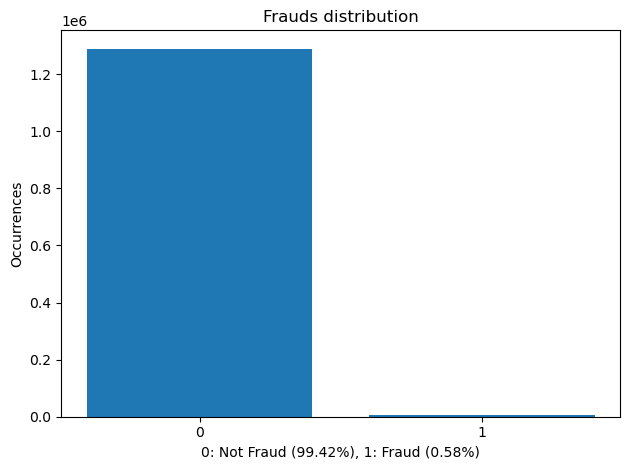

In [6]:
frauds=df["is_fraud"].value_counts()
fig,ax=plt.subplots()
ax.bar(frauds.index,frauds.values)
ax.set_xticks(frauds.index)
ax.set_title("Frauds distribution")
ax.set_xlabel(f"0: Not Fraud ({round(frauds[0]/frauds.sum()*100,2)}%), 1: Fraud ({round(frauds[1]/frauds.sum()*100,2)}%)")
ax.set_ylabel("Occurrences")

plt.tight_layout()
plt.show()

Fraudulent transactions account for ~0.58% of the dataset — a severe class imbalance, suggesting **PR-AUC** is the appropriate evaluation metric throughout. 

#### Temporal patterns — `trans_date_trans_time`

Transaction timestamps are the first candidate for temporal signal. We examine the fraud rate by hour of day (both absolute count and rate), then check whether the day of the week, day of the month, or month of the year add further information.

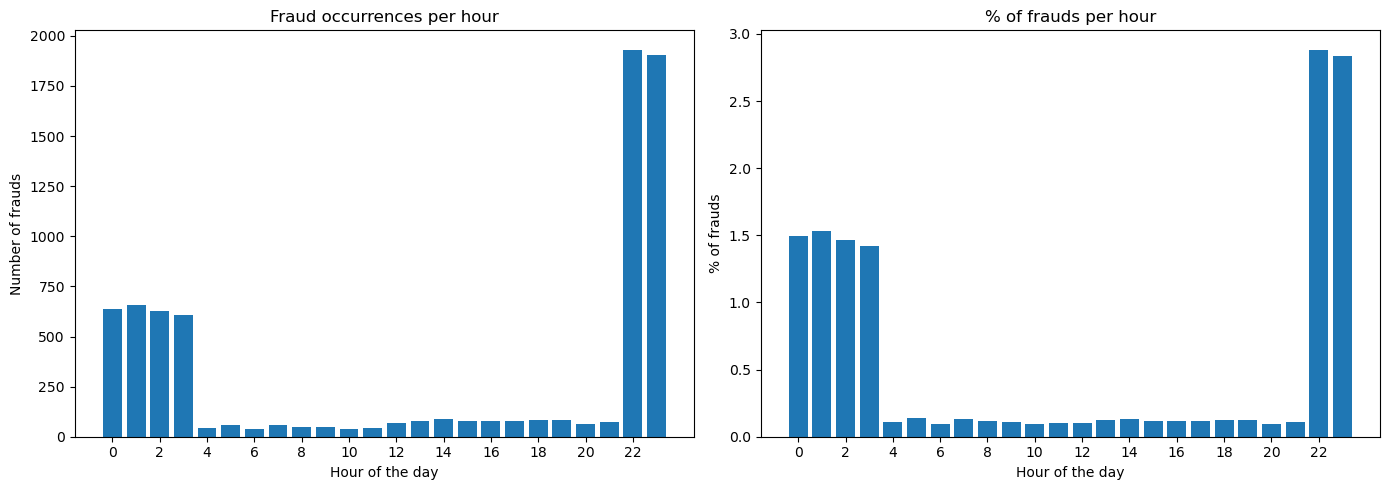

In [7]:
trans_hour=df["trans_date_trans_time"].dt.hour
fraud_hour=df["trans_date_trans_time"][df["is_fraud"]==1].dt.hour
trans_hour_counts=trans_hour.value_counts().sort_index()
fraud_hour_counts=fraud_hour.value_counts().sort_index()
perc_frauds=fraud_hour_counts/trans_hour_counts*100

fig,ax=plt.subplots(ncols=2, figsize=(14, 5))
ax[0].bar(np.arange(24),fraud_hour_counts)
ax[0].set_xticks(np.arange(0,24,2))
ax[0].set_xlabel("Hour of the day")
ax[0].set_ylabel("Number of frauds")
ax[0].set_title("Fraud occurrences per hour")

ax[1].bar(np.arange(24),perc_frauds)
ax[1].set_xticks(np.arange(0,24,2))
ax[1].set_xlabel("Hour of the day")
ax[1].set_ylabel("% of frauds")
ax[1].set_title("% of frauds per hour")

plt.tight_layout()
plt.show()


Fraud is strongly concentrated between **10 PM and 3 AM** — both in absolute count and as a percentage of hourly transactions.

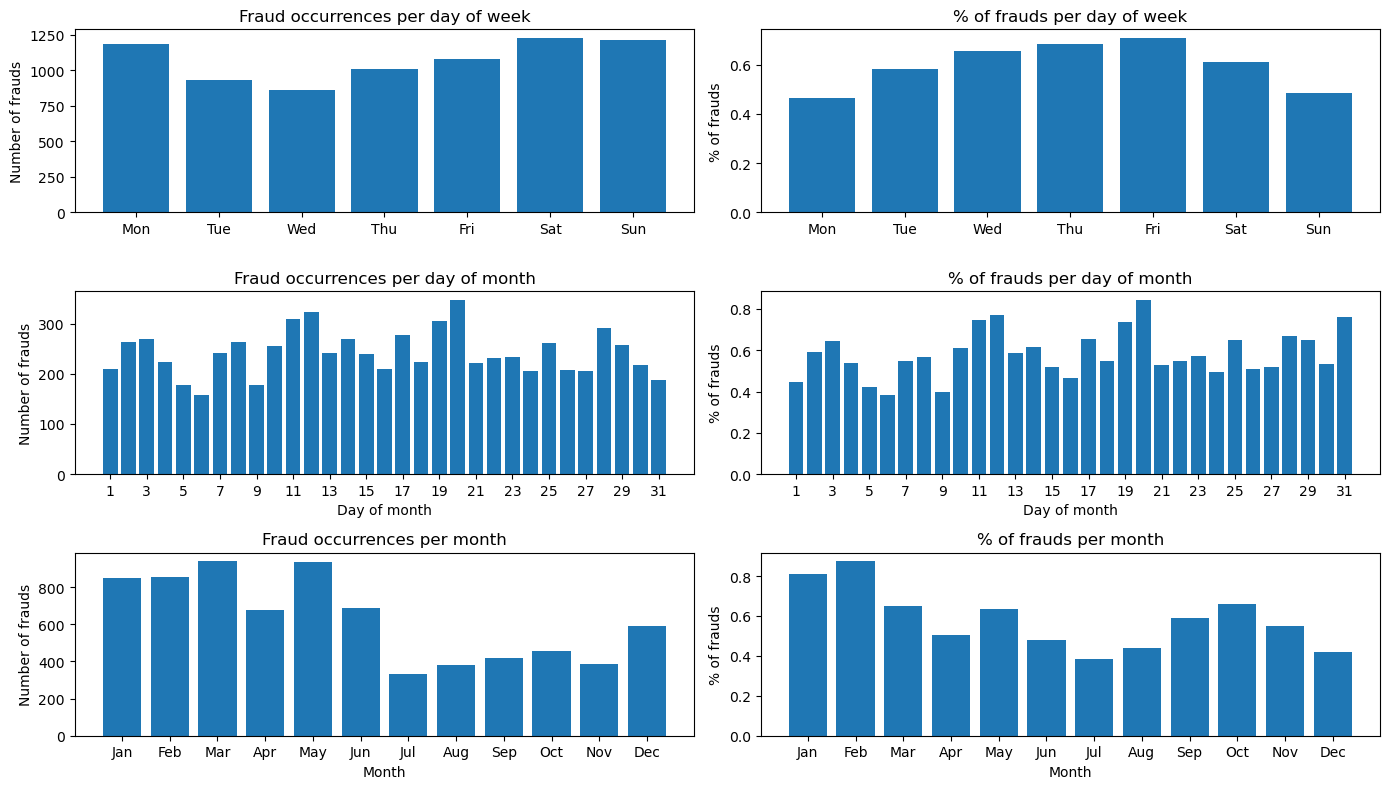

In [8]:
fig, ax = plt.subplots(nrows=3, ncols=2,figsize=(14, 8))

trans_dow = df["trans_date_trans_time"].dt.dayofweek
fraud_dow = df["trans_date_trans_time"][df["is_fraud"]==1].dt.dayofweek
trans_dow_counts = trans_dow.value_counts().sort_index()
fraud_dow_counts = fraud_dow.value_counts().sort_index()
perc_frauds_dow = (fraud_dow_counts / trans_dow_counts) * 100

dow = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

ax[0, 0].bar(trans_dow_counts.index, fraud_dow_counts)
ax[0, 0].set_xticks(range(7))
ax[0, 0].set_xticklabels(dow)
ax[0, 0].set_ylabel("Number of frauds")
ax[0, 0].set_title("Fraud occurrences per day of week")

ax[0, 1].bar(trans_dow_counts.index, perc_frauds_dow)
ax[0, 1].set_xticks(range(7))
ax[0, 1].set_xticklabels(dow)
ax[0, 1].set_ylabel("% of frauds")
ax[0, 1].set_title("% of frauds per day of week")

trans_dom = df["trans_date_trans_time"].dt.day
fraud_dom = df["trans_date_trans_time"][df["is_fraud"]==1].dt.day
trans_dom_counts = trans_dom.value_counts().sort_index()
fraud_dom_counts = fraud_dom.value_counts().sort_index()
perc_frauds_dom = (fraud_dom_counts / trans_dom_counts) * 100

ax[1, 0].bar(trans_dom_counts.index, fraud_dom_counts)
ax[1, 0].set_xticks(range(1, 32, 2))
ax[1, 0].set_xlabel("Day of month")
ax[1, 0].set_ylabel("Number of frauds")
ax[1, 0].set_title("Fraud occurrences per day of month")

ax[1, 1].bar(trans_dom_counts.index, perc_frauds_dom)
ax[1, 1].set_xticks(range(1, 32, 2))
ax[1, 1].set_xlabel("Day of month")
ax[1, 1].set_ylabel("% of frauds")
ax[1, 1].set_title("% of frauds per day of month")

trans_month = df["trans_date_trans_time"].dt.month
fraud_month = df["trans_date_trans_time"][df["is_fraud"] == 1].dt.month
trans_month_counts = trans_month.value_counts().sort_index()
fraud_month_counts = fraud_month.value_counts().sort_index()
perc_frauds_month = (fraud_month_counts / trans_month_counts) * 100

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

ax[2,0].bar(fraud_month_counts.index, fraud_month_counts.values)
ax[2,0].set_xticks(range(1, 13))
ax[2,0].set_xticklabels(months)
ax[2,0].set_xlabel("Month")
ax[2,0].set_ylabel("Number of frauds")
ax[2,0].set_title("Fraud occurrences per month")

ax[2,1].bar(perc_frauds_month.index, perc_frauds_month.values)
ax[2,1].set_xticks(range(1, 13))
ax[2,1].set_xticklabels(months)
ax[2,1].set_xlabel("Month")
ax[2,1].set_ylabel("% of frauds")
ax[2,1].set_title("% of frauds per month")

plt.tight_layout()
plt.show()

Broadening the temporal granularity yields no further signal. Neither the day of the week, day of the month, nor month of the year show a consistent pattern in the fraud rate. Hour of day is the only informative temporal dimension.

#### Transaction category — `category`

With 14 distinct categories, `category` provides a coarse partition of spending behaviour. We compare both absolute fraud count and per-category fraud rate to identify which categories are over-represented among fraudulent transactions.

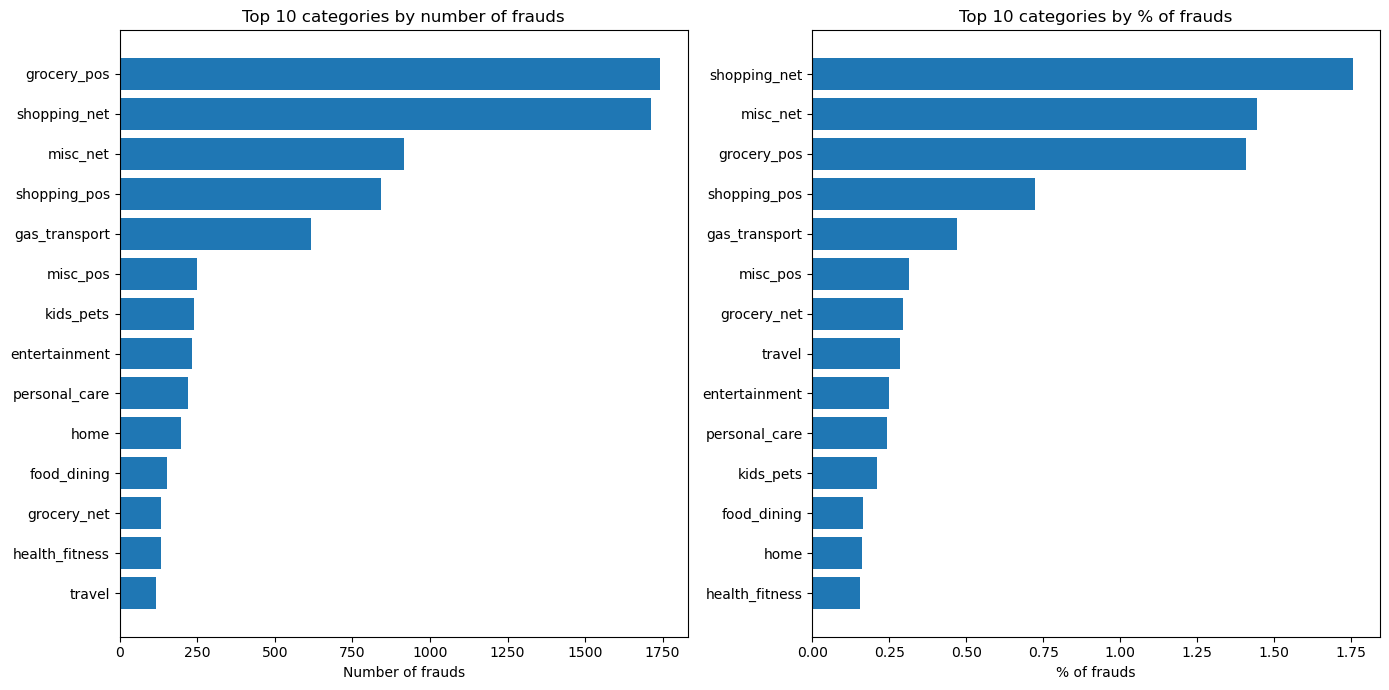

In [9]:
trans_cat = df["category"].value_counts()
fraud_cat = df[df["is_fraud"] == 1]["category"].value_counts()
perc_frauds_cat = (fraud_cat / trans_cat * 100).dropna().sort_values(ascending=True)
fraud_cat_sorted = fraud_cat.sort_values(ascending=True)

fig, ax = plt.subplots(ncols=2, figsize=(14, 7))

ax[0].barh(fraud_cat_sorted.index, fraud_cat_sorted.values)
ax[0].set_xlabel("Number of frauds")
ax[0].set_title("Top 10 categories by number of frauds")

ax[1].barh(perc_frauds_cat.index, perc_frauds_cat.values)
ax[1].set_xlabel("% of frauds")
ax[1].set_title("Top 10 categories by % of frauds")

plt.tight_layout()
plt.show()

The signal is clear: while everyday categories (groceries, shopping) dominate in absolute transaction count, the fraud rate is concentrated in online categories — those ending with the *_net* suffix. 

#### Merchant identity — `merchant`

We focus on the top 10 by absolute fraud count and by fraud rate, applying the same dual-perspective approach used throughout the EDA.

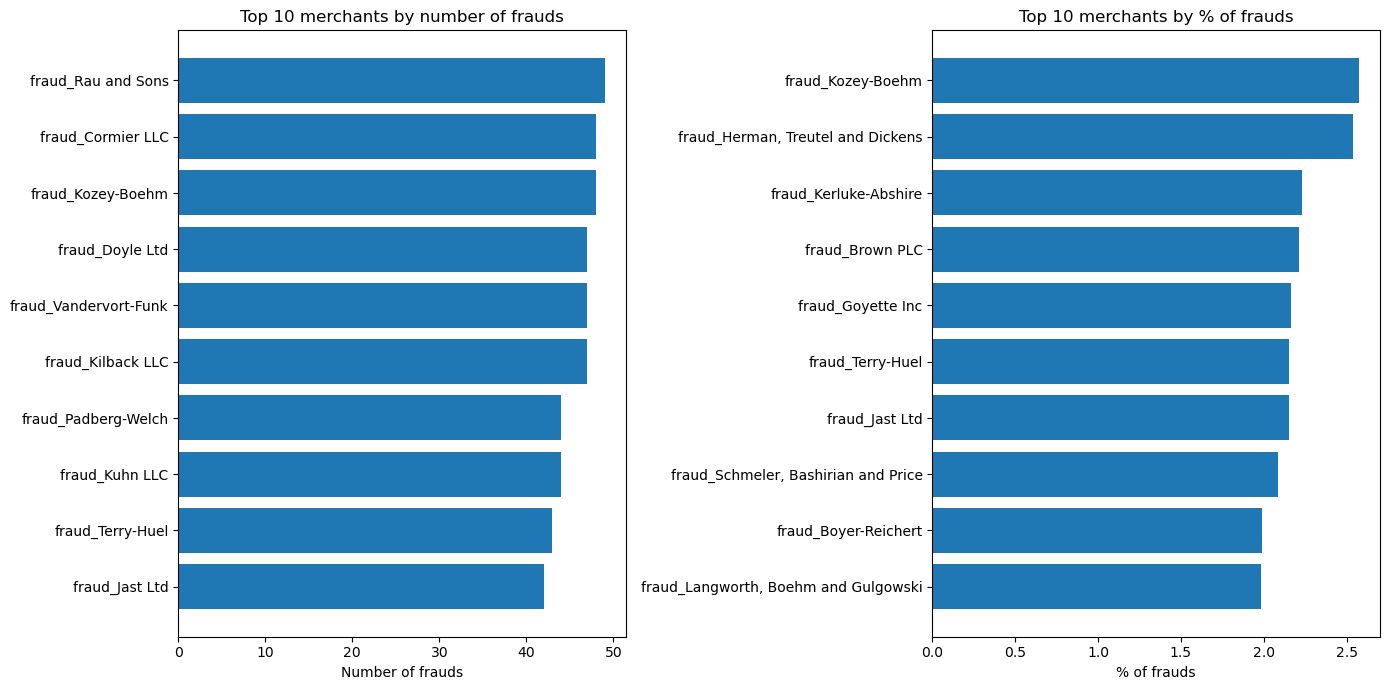

In [10]:
trans_merch = df['merchant'].value_counts()
fraud_merch = df[df['is_fraud'] == 1]['merchant'].value_counts()

top20_abs = fraud_merch.sort_values(ascending=True).tail(10)
top20_perc = (fraud_merch / trans_merch * 100).dropna().sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(ncols=2, figsize=(14, 7))

ax[0].barh(top20_abs.index, top20_abs.values)
ax[0].set_xlabel("Number of frauds")
ax[0].set_title("Top 10 merchants by number of frauds")

ax[1].barh(top20_perc.index, top20_perc.values)
ax[1].set_xlabel("% of frauds")
ax[1].set_title("Top 10 merchants by % of frauds")

plt.tight_layout()
plt.show()

No consistent signal emerges. Merchants with the highest fraud *rates* are typically those with very few transactions. With ~700 unique values, `merchant` will be dropped.

#### Transaction amount — `amt`

Transaction amounts span several orders of magnitude and are strongly right-skewed for both classes. We compare summary statistics, boxplots, and empirical distributions to quantify the difference between legitimate and fraudulent spending.

Stats legit transactions
count    1.289169e+06
mean     6.766711e+01
std      1.540080e+02
min      1.000000e+00
25%      9.610000e+00
50%      4.728000e+01
75%      8.254000e+01
max      2.894890e+04
Name: amt, dtype: float64

Stats frauds
count     7506.000000
mean      1251.711756
std        793.192010
min        497.384872
25%        865.925946
50%       1075.807895
75%       1453.738845
max      11016.148354
Name: amt, dtype: float64


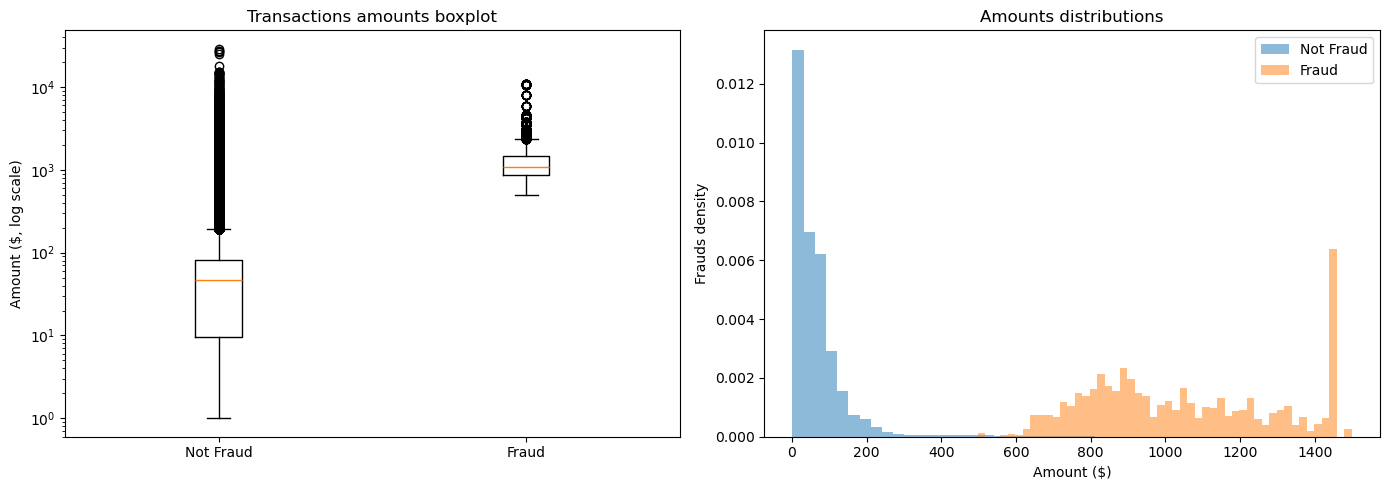

In [11]:
print("Stats legit transactions")
print(df[df['is_fraud'] == 0]['amt'].describe())
print("\nStats frauds")
print(df[df['is_fraud'] == 1]['amt'].describe())

fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].boxplot([df[df["is_fraud"]==0]["amt"], df[df["is_fraud"]==1]["amt"]], tick_labels=["Not Fraud", "Fraud"])
ax[0].set_yscale("log") 
ax[0].set_ylabel("Amount ($, log scale)")
ax[0].set_title("Transactions amounts boxplot")

ax[1].hist(df[(df["is_fraud"]==0) & (df["amt"] < 1500)]["amt"], bins=50, alpha=0.5, label="Not Fraud", density=True)
ax[1].hist(df[(df["is_fraud"]==1) & (df["amt"] < 1500)]["amt"], bins=50, alpha=0.5, label="Fraud", density=True)
ax[1].set_xlabel("Amount ($)")
ax[1].set_ylabel("Frauds density")
ax[1].set_title("Amounts distributions")
ax[1].legend()

plt.tight_layout()
plt.show()

The distributions diverge sharply: legitimate transactions cluster below $100 (median ~$47), while fraudulent amounts are dramatically elevated — the median fraud amount (~$1,076) is roughly 23× the legitimate median. This strong separation makes `amt` a strong discriminative raw feature.

#### Cardholder age — `dob`

We examine whether the cardholder's birth year associates with fraud likelihood. Any observed pattern could reflect demographic targeting or simply mirror the age distribution of the active cardholder population.

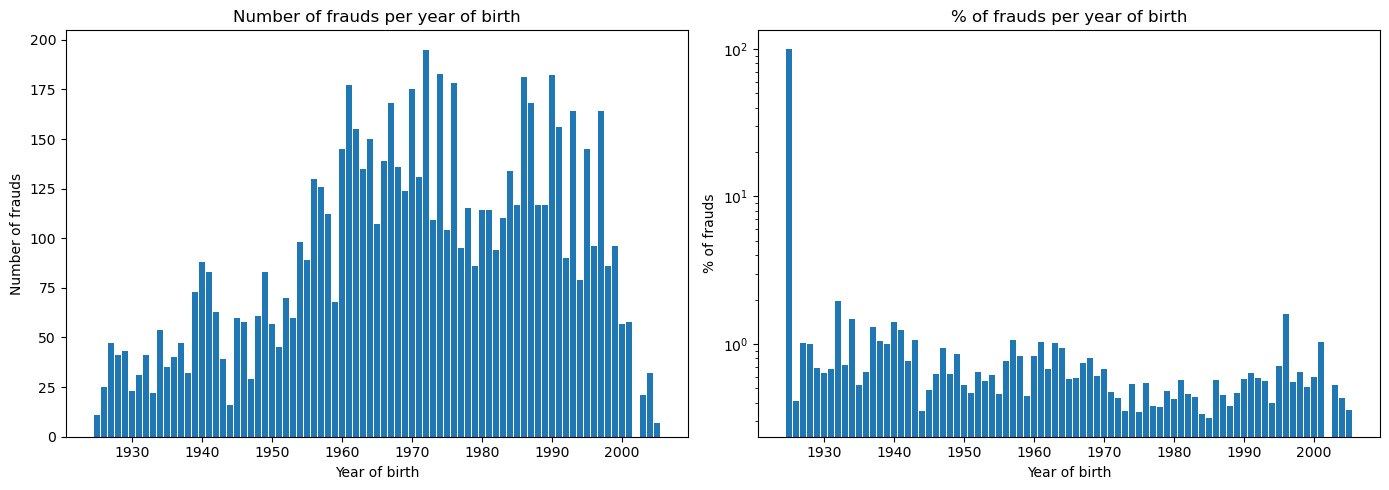

In [12]:
trans_yob = df["dob"].dt.year
fraud_yob = df[df["is_fraud"] == 1]["dob"].dt.year
trans_yob_counts = trans_yob.value_counts().sort_index()
fraud_yob_counts = fraud_yob.value_counts().sort_index()
perc_frauds_yob = (fraud_yob_counts / trans_yob_counts) * 100

fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].bar(fraud_yob_counts.index, fraud_yob_counts.values)
ax[0].set_xlabel("Year of birth")
ax[0].set_ylabel("Number of frauds")
ax[0].set_title("Number of frauds per year of birth")


ax[1].bar(perc_frauds_yob.index, perc_frauds_yob.values)
ax[1].set_xlabel("Year of birth")
ax[1].set_ylabel("% of frauds")
ax[1].set_yscale("log")
ax[1].set_title("% of frauds per year of birth")


plt.tight_layout()
plt.show()

In [13]:
df[df["dob"].dt.year==1925][["cc_num","is_fraud"]].value_counts()

cc_num            is_fraud
4492677353108006  1           11
Name: count, dtype: int64

The fraud count by birth year mirrors the active cardholder population (concentrated 1960–2000), with no age-related signal in the fraud rate. The outlier at 1925 is explained by a single compromised card. `dob` carries no predictive signal and will be dropped.

#### Cardholder gender — `gender`

We check whether fraud rates differ between male and female cardholders, comparing both the absolute number of fraudulent transactions and the per-gender fraud rate.

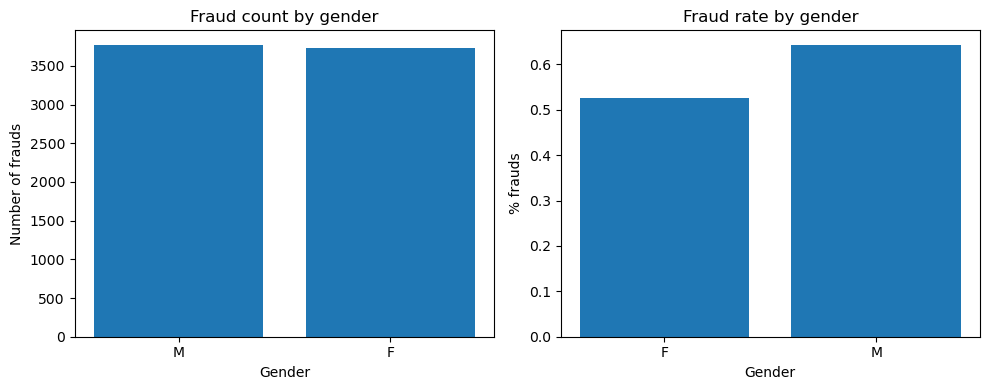

In [14]:
trans_gender = df["gender"].value_counts()
fraud_gender = df[df["is_fraud"] == 1]["gender"].value_counts()
perc_frauds_gender = (fraud_gender / trans_gender * 100).dropna().sort_values(ascending=True)

fig, ax = plt.subplots(ncols=2, figsize=(10, 4))

ax[0].bar(fraud_gender.index, fraud_gender.values)
ax[0].set_xlabel("Gender")
ax[0].set_ylabel("Number of frauds")
ax[0].set_title("Fraud count by gender")

ax[1].bar(perc_frauds_gender.index, perc_frauds_gender.values)
ax[1].set_xlabel("Gender")
ax[1].set_ylabel("% frauds")
ax[1].set_title("Fraud rate by gender")

plt.tight_layout()
plt.show()

Fraud counts and rates are nearly identical across genders with no meaningful difference in fraud rate. `gender` carries no predictive signal and will be dropped.

#### Cardholder occupation — `job`

The dataset contains several hundred distinct job titles. We examine whether any occupation is systematically over-represented among fraudulent transactions for the top 10 entries by fraud count and fraud rate.

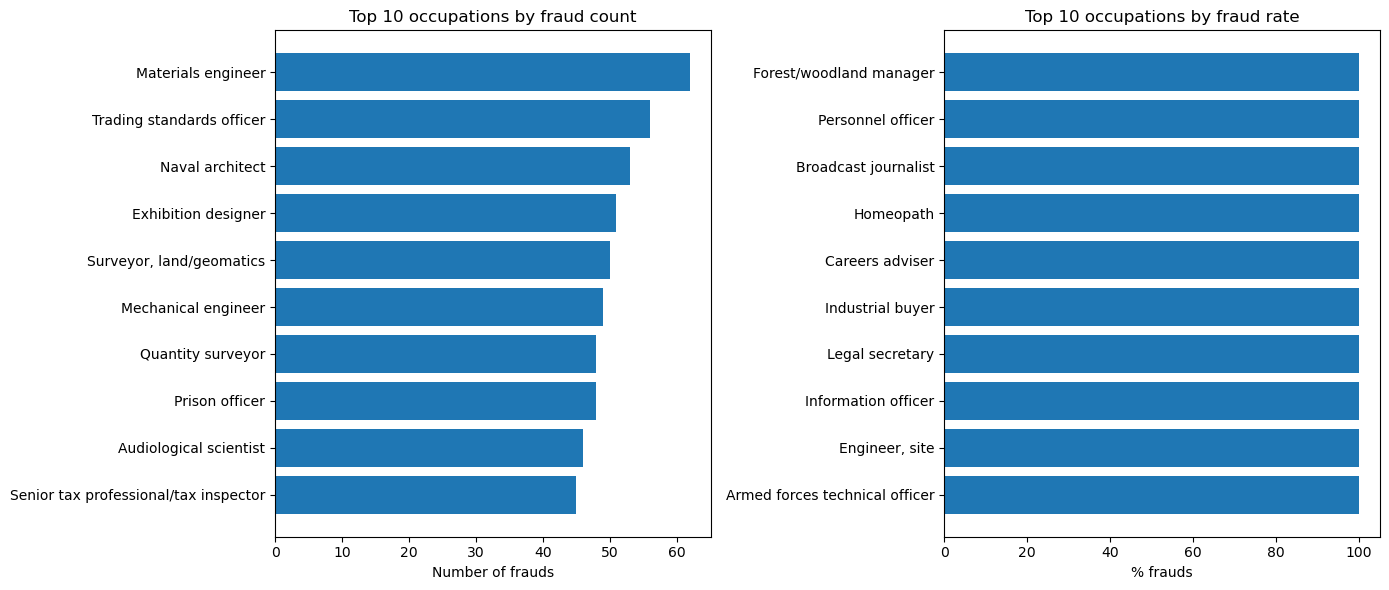

In [15]:
trans_job = df["job"].value_counts()
fraud_job = df[df["is_fraud"] == 1]["job"].value_counts()
perc_frauds_job = (fraud_job / trans_job * 100).dropna()

top_n = 10
fig, ax = plt.subplots(ncols=2, figsize=(14, 6))

fraud_top = fraud_job.head(top_n).sort_values()
ax[0].barh(fraud_top.index, fraud_top.values)
ax[0].set_xlabel("Number of frauds")
ax[0].set_title(f"Top {top_n} occupations by fraud count")

perc_top = perc_frauds_job.sort_values(ascending=False).head(top_n).sort_values()
ax[1].barh(perc_top.index, perc_top.values)
ax[1].set_xlabel("% frauds")
ax[1].set_title(f"Top {top_n} occupations by fraud rate")

plt.tight_layout()
plt.show()

In [16]:
top_rate_jobs = perc_frauds_job.sort_values(ascending=False).head(10).index
df[df["job"].isin(top_rate_jobs)].groupby("job")["is_fraud"].value_counts()

job                             is_fraud
Armed forces technical officer  1            8
Broadcast journalist            1            9
Careers adviser                 1           15
Engineer, site                  1           12
Forest/woodland manager         1            9
Homeopath                       1           11
Industrial buyer                1           10
Information officer             1            8
Legal secretary                 1           12
Personnel officer               1           12
Name: count, dtype: int64

No occupation is disproportionately associated with fraud. The top entries by absolute count simply reflect the most common jobs in the cardholder population, with no meaningful elevation in fraud rate. The apparent 100% fraud rates in the right panel are a sparsity artefact: each of those occupations belongs to a single cardholder whose card was entirely compromised. With ~500 distinct job titles, `job` would introduce a high-cardinality categorical with no stable signal and will be dropped.

#### Home-to-merchant distance

Using the Haversine formula, we compute the great-circle distance between the cardholder's registered home address (`lat`, `long`) and the merchant location (`merch_lat`, `merch_long`) to check whether fraudsters tend to operate far from the cardholder's home.

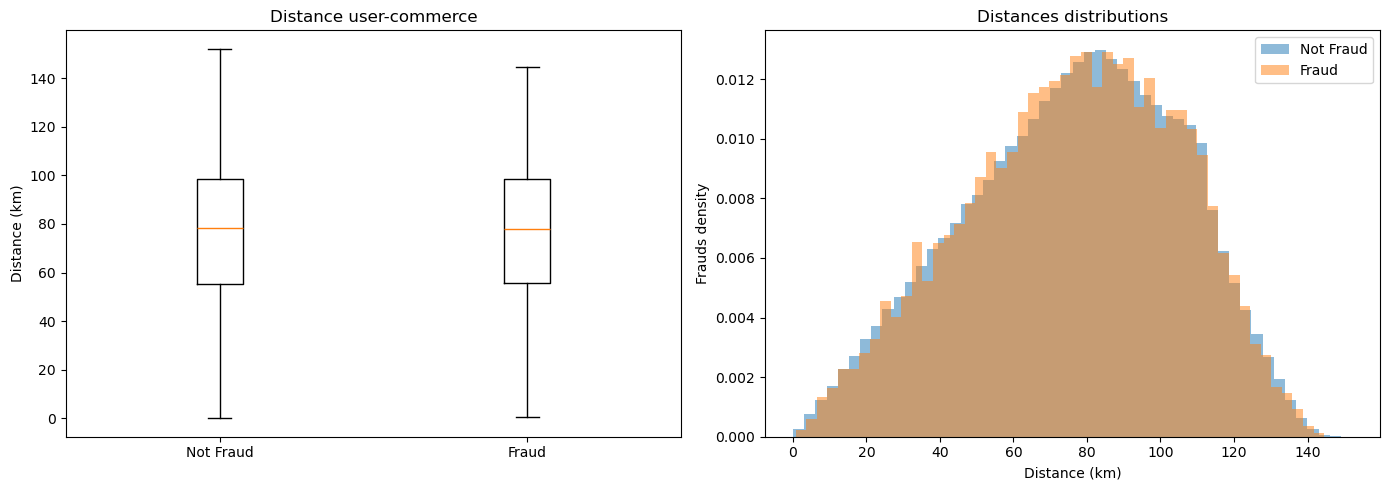

In [17]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0 
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    d=R*c
    return d

dist_km = haversine_distance(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].boxplot([dist_km[df["is_fraud"]==0], dist_km[df["is_fraud"]==1]], tick_labels=["Not Fraud", "Fraud"])
ax[0].set_ylabel("Distance (km)")
ax[0].set_title("Distance user-commerce")

ax[1].hist(dist_km[df["is_fraud"]==0], bins=50, alpha=0.5, label="Not Fraud", density=True)
ax[1].hist(dist_km[df["is_fraud"]==1], bins=50, alpha=0.5, label="Fraud", density=True)
ax[1].set_xlabel("Distance (km)")
ax[1].set_ylabel("Frauds density")
ax[1].set_title("Distances distributions")
ax[1].legend()

plt.tight_layout()
plt.show()

Both boxplots and empirical distributions are nearly identical for fraudulent and legitimate transactions — geographical distance from home carries no useful signal.

#### Geographic context — `city_pop` and `state`

We check the two remaining geographic features: the population of the cardholder's city of residence and the US state. Raw lat/long coordinates are not analysed at finer granularity — the high dimensionality would introduce noise rather than signal.

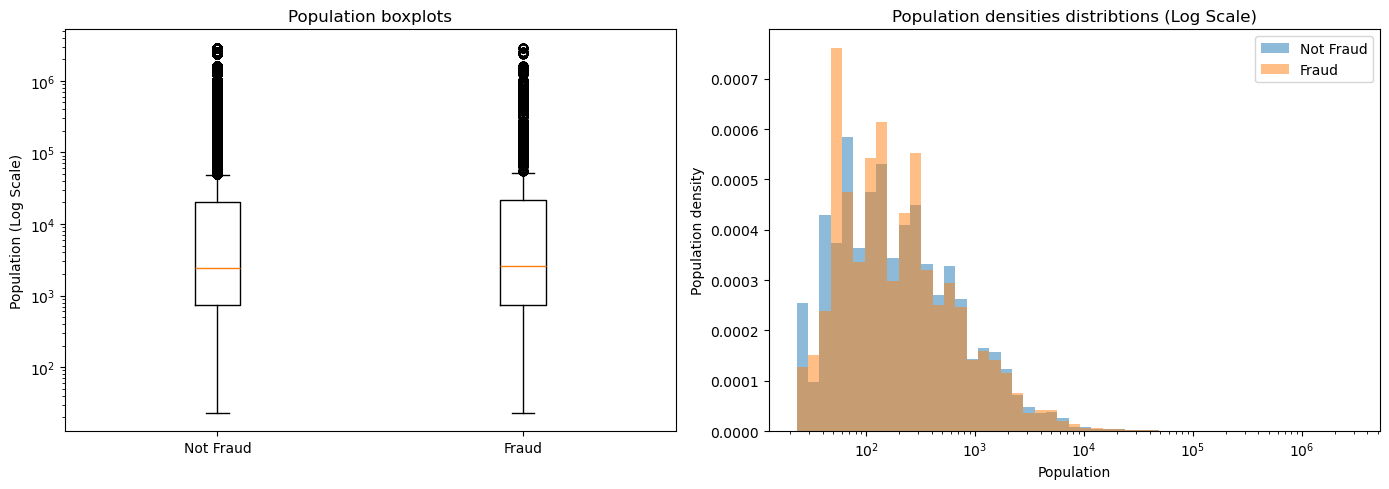

In [18]:
fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].boxplot([df[df["is_fraud"]==0]["city_pop"], df[df["is_fraud"]==1]["city_pop"]], tick_labels=["Not Fraud", "Fraud"])
ax[0].set_yscale("log")
ax[0].set_ylabel("Population (Log Scale)")
ax[0].set_title("Population boxplots")

bins = np.logspace(np.log10(df['city_pop'].min()), np.log10(df['city_pop'].max()), 50)
ax[1].hist(df[df["is_fraud"]==0]["city_pop"], bins=bins, alpha=0.5, label="Not Fraud", density=True)
ax[1].hist(df[df["is_fraud"]==1]["city_pop"], bins=bins, alpha=0.5, label="Fraud", density=True)
ax[1].set_xscale("log")
ax[1].set_xlabel("Population")
ax[1].set_ylabel("Population density")
ax[1].set_title("Population densities distribtions (Log Scale)")
ax[1].legend()

plt.tight_layout()
plt.show()

City population distributions are nearly identical across classes — no signal here either.

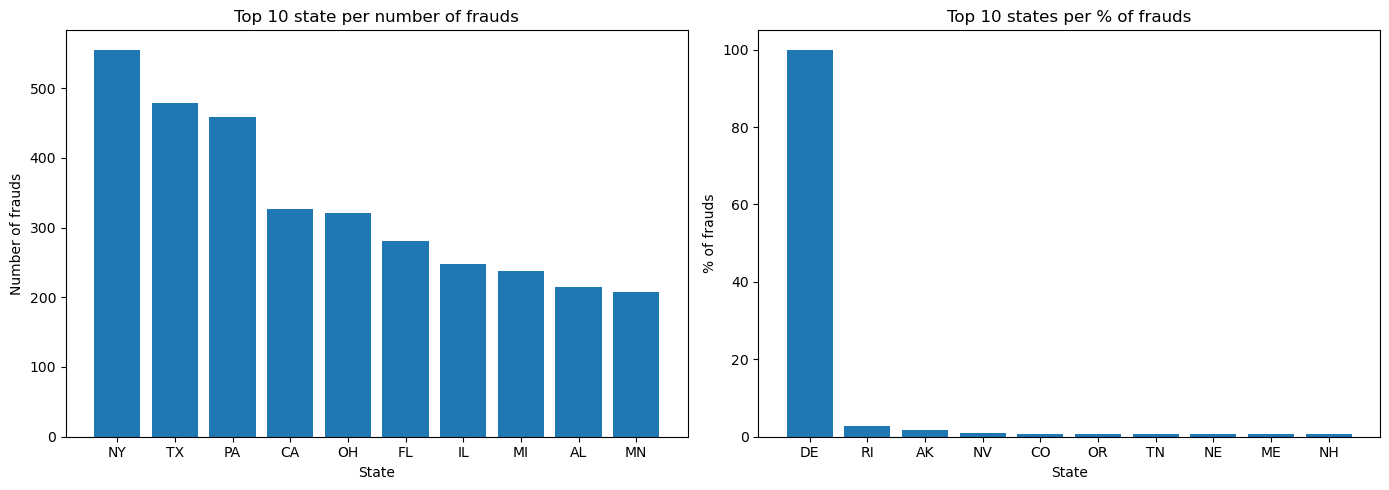

In [19]:
trans_state = df['state'].value_counts()
fraud_state = df[df['is_fraud']==1]['state'].value_counts()

top10_abs = fraud_state.sort_values(ascending=False).head(10)
perc_state = (fraud_state / trans_state * 100).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].bar(top10_abs.index, top10_abs.values)
ax[0].set_xlabel("State")
ax[0].set_ylabel("Number of frauds")
ax[0].set_title("Top 10 state per number of frauds")

ax[1].bar(perc_state.index, perc_state.values)
ax[1].set_xlabel("State")
ax[1].set_ylabel("% of frauds")
ax[1].set_title("Top 10 states per % of frauds")

plt.tight_layout()
plt.show()

In [20]:
df[df['state']=='DE'][["cc_num","state","is_fraud"]].value_counts()

cc_num            state  is_fraud
6011826317034777  DE     1           9
Name: count, dtype: int64

No state shows a disproportionately high fraud count. Delaware (DE) appears to stand out in relative terms, but the lookup confirms it is driven by a single compromised card — the same artefact as the 1925 birth year. No geographic feature at any granularity carries actionable signal.

#### Inter-transaction time — `hours_since_last_trans`

Beyond the hour of the day, fraud may also manifest as an unusual pace of transactions. We compute the time elapsed between consecutive transactions on the same card and compare the distributions.

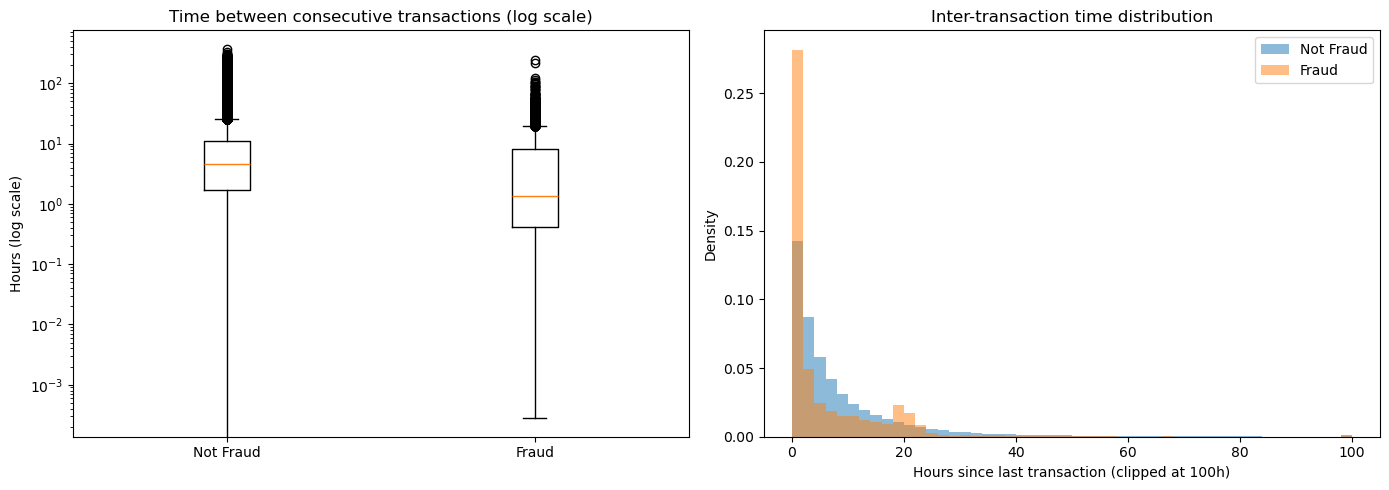

Median inter-transaction time — Not Fraud: 4.6h
Median inter-transaction time — Fraud:     1.4h


In [21]:
df_vel = df[['cc_num', 'unix_time', 'is_fraud']].sort_values(['cc_num', 'unix_time'])
df_vel['hours_since_last'] = df_vel.groupby('cc_num')['unix_time'].diff() / 3600

legit_h = df_vel[df_vel['is_fraud'] == 0]['hours_since_last'].dropna()
fraud_h = df_vel[df_vel['is_fraud'] == 1]['hours_since_last'].dropna()

clip_h = 100
fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].boxplot([legit_h, fraud_h], tick_labels=['Not Fraud', 'Fraud'])
ax[0].set_yscale('log')
ax[0].set_ylabel('Hours (log scale)')
ax[0].set_title('Time between consecutive transactions (log scale)')

ax[1].hist(legit_h.clip(upper=clip_h), bins=50, alpha=0.5, label='Not Fraud', density=True)
ax[1].hist(fraud_h.clip(upper=clip_h), bins=50, alpha=0.5, label='Fraud', density=True)
ax[1].set_xlabel(f'Hours since last transaction (clipped at {clip_h}h)')
ax[1].set_ylabel('Density')
ax[1].set_title('Inter-transaction time distribution')
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Median inter-transaction time — Not Fraud: {legit_h.median():.1f}h")
print(f"Median inter-transaction time — Fraud:     {fraud_h.median():.1f}h")

Fraudulent transactions occur significantly closer together in time: the median interval drops from 4.6 hours (legitimate) to 1.4 hours (fraud) — a 3.3× difference. This burst pattern is consistent with a card being used intensively in a short window. `hours_since_last_trans` is a strong feature candidate.

#### Transaction history depth — `cc_num`

The sequential models (LSTM-AE and GRU-AE) represent each transaction as the final step of a fixed-length card history of `SEQ_LEN = 10`. We verify that the large majority of cards have accumulated at least 10 transactions in the training set, so that sequences are not predominantly padded.

count     983
mean     1319
std       812
min         7
25%       525
50%      1054
75%      2025
max      3123

Cards with >= 10 transactions: 96.4%


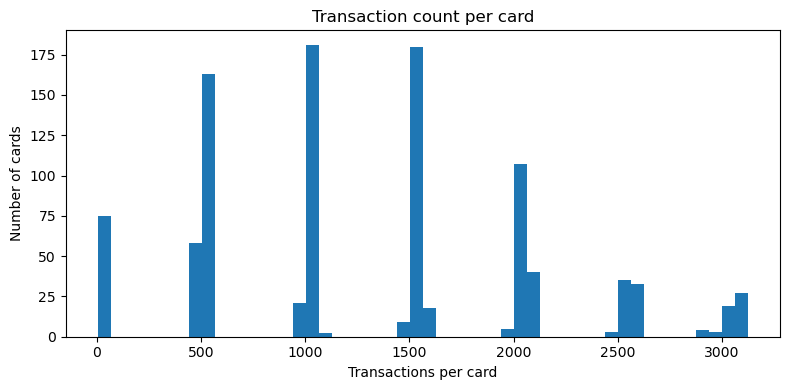

In [22]:
card_tx_count = df.groupby("cc_num").size()

print(card_tx_count.describe().astype(int).to_string())
print(f"\nCards with >= 10 transactions: {(card_tx_count >= 10).mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(card_tx_count, bins=50)
ax.set_xlabel("Transactions per card")
ax.set_ylabel("Number of cards")
ax.set_title("Transaction count per card")
plt.tight_layout()
plt.show()

96.4% of cards have at least 10 transactions in the training set, with a median of 1,054 transactions per card — confirming that `SEQ_LEN = 10` is a very conservative window. The 35 cards below the threshold (minimum: 7 transactions) are the only ones where every sequence requires padding; for all other cards, padding affects only the first 9 transactions. 

#### Amount z-scores — `amt_zscore_cat` and `amt_zscore_card`

The raw `amt` carries signal, but its discriminative power increases when normalised relative to the expected spend for a given context. We engineer two complementary z-scores to capture both dimensions.

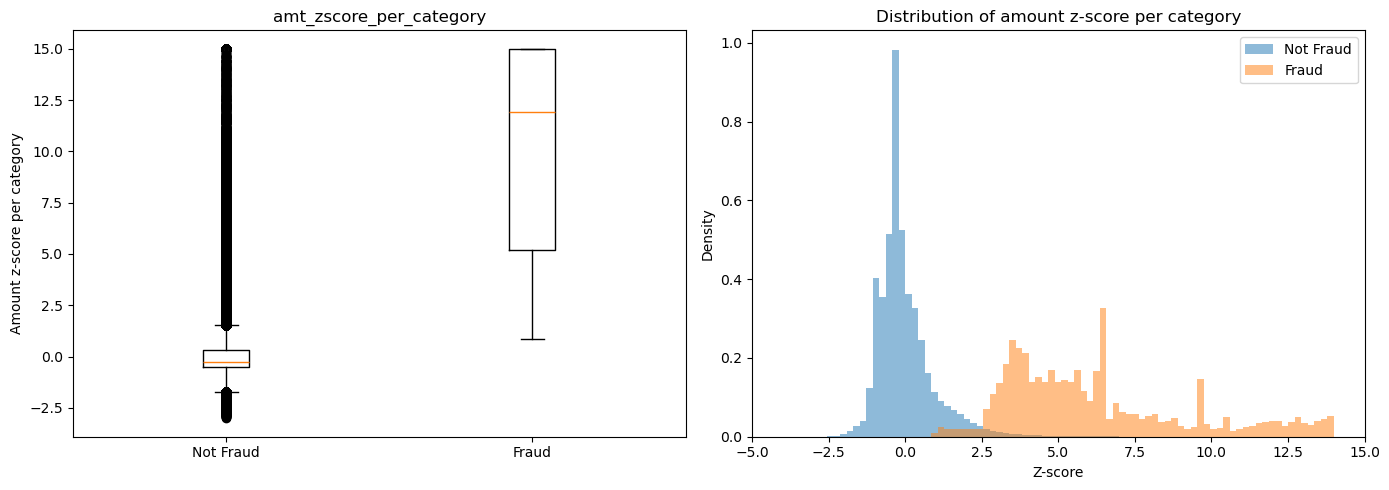

Median z-score amount per category — Not Fraud: -0.26
Median z-score amount per category — Fraud:     11.94


In [23]:
cat_mean = df[df['is_fraud'] == 0].groupby('category')['amt'].mean()
cat_std  = df[df['is_fraud'] == 0].groupby('category')['amt'].std()

amt_z   = (df['amt'] - df['category'].map(cat_mean)) / (df['category'].map(cat_std) + 1e-6)
legit_z = amt_z[df['is_fraud'] == 0]
fraud_z = amt_z[df['is_fraud'] == 1]

fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].boxplot([legit_z.clip(-5, 15), fraud_z.clip(-5, 15)], tick_labels=['Not Fraud', 'Fraud'])
ax[0].set_ylabel('Amount z-score per category')
ax[0].set_title('amt_zscore_per_category')

bins = np.linspace(-7, 14, 100)
ax[1].hist(legit_z, bins=bins, alpha=0.5, label='Not Fraud', density=True)
ax[1].hist(fraud_z, bins=bins, alpha=0.5, label='Fraud',     density=True)
ax[1].set_xlim(-5, 15)
ax[1].set_xlabel('Z-score')
ax[1].set_ylabel('Density')
ax[1].set_title('Distribution of amount z-score per category')
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Median z-score amount per category — Not Fraud: {legit_z.median():.2f}")
print(f"Median z-score amount per category — Fraud:     {fraud_z.median():.2f}")

`amt_zscore_cat` reveals a clear separation: fraudulent amounts sit far above the category baseline (median z-score ≈ +12), confirming that fraud consistently involves purchases atypical for the transaction category. Legitimate transactions cluster near zero (median ≈ −0.3), as expected from a z-score.

However, two cardholders in the same category can have very different typical spending levels. The following feature captures how anomalous a given amount is for this specific card's history.

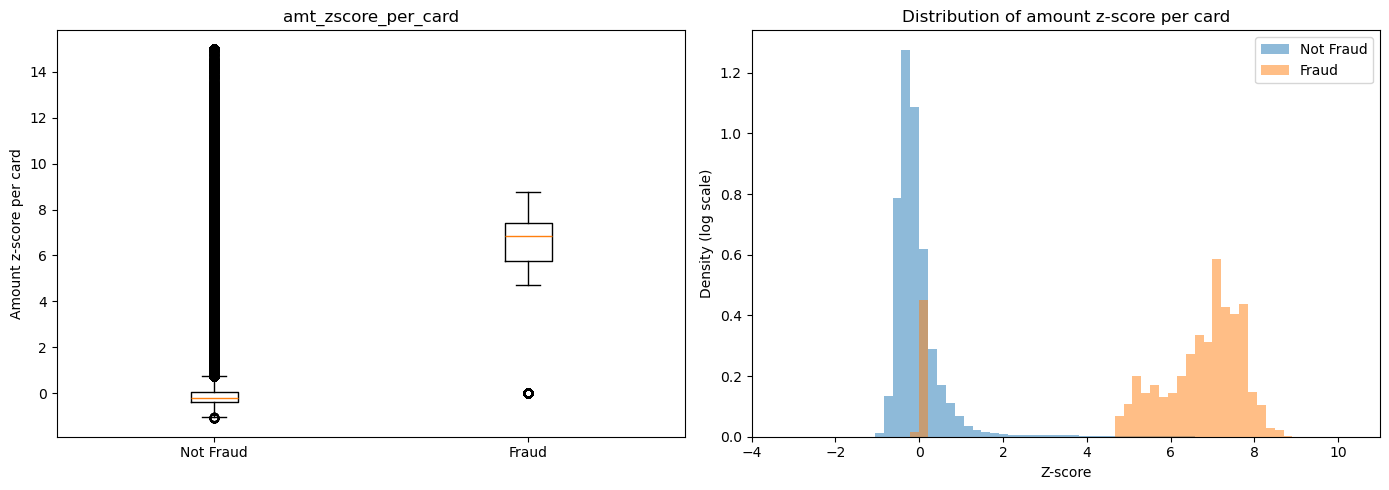

Median z-score amount per card — Not Fraud: -0.19
Median z-score amount per card — Fraud:     6.85


In [24]:
card_mean  = df.groupby('cc_num')['amt'].transform('mean')
card_std   = df.groupby('cc_num')['amt'].transform('std')
amt_z_card = (df['amt'] - card_mean) / (card_std + 1e-6)

legit_zc = amt_z_card[df['is_fraud'] == 0]
fraud_zc = amt_z_card[df['is_fraud'] == 1]

fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].boxplot([legit_zc.clip(-5, 15), fraud_zc.clip(-5, 15)], tick_labels=['Not Fraud', 'Fraud'])
ax[0].set_ylabel('Amount z-score per card')
ax[0].set_title('amt_zscore_per_card')

bins = np.linspace(-7, 14, 100)
ax[1].hist(legit_zc, bins=bins, alpha=0.5, label='Not Fraud', density=True)
ax[1].hist(fraud_zc, bins=bins, alpha=0.5, label='Fraud',     density=True)
ax[1].set_xlim(-4, 11)

ax[1].set_xlabel('Z-score')
ax[1].set_ylabel('Density (log scale)')
ax[1].set_title('Distribution of amount z-score per card')
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Median z-score amount per card — Not Fraud: {legit_zc.median():.2f}")
print(f"Median z-score amount per card — Fraud:     {fraud_zc.median():.2f}")

The card-level z-score amplifies the signal further: fraudulent amounts are systematically extreme relative to the card's own history (median z ≈ +6.9), while legitimate transactions cluster near zero (median ≈ −0.2). `amt_zscore_card` is therefore a strong feature alongside `amt_zscore_cat`. Note that for this visualisation the z-score is computed using the full per-card mean — a non-causal approximation used here solely to quantify the signal; the causal implementation used in the models is described below.

**On temporal leakage — why the two z-scores are computed differently in the models.**

- **`amt_zscore_cat`** uses the mean and std of all legitimate training transactions in each category. Each category aggregates tens of thousands of transactions, so the contribution of any single one to the category mean is negligible: using the full statistic introduces no meaningful leakage and is standard practice.

- **`amt_zscore_card`** normalises by a per-card mean. A card may have only a few hundred transactions, so using the full mean would incorporate future transactions when normalising past ones — genuine temporal leakage. In the models, an expanding window is therefore used: the z-score at time *t* uses only the mean of transactions 1 through *t*−1, making the normalisation strictly causal.

---

## EDA Recap — Feature Selection and Transformations

The EDA established which raw columns carry discriminative signal, which engineered features to derive from them, and how each model family requires different preprocessing. This section consolidates those decisions before modelling begins.

---

### Features retained

All models share the same six core signals identified in the EDA, plus `category` as a categorical input.

| Feature | EDA finding | Source |
|---|---|---|
| `amt` | Fraud median (~$1,076) is 23× the legitimate median (~$47); strong distributional separation | Raw |
| `category` | Fraud concentrated in online (`_net`) categories; channel type is the key categorical signal | Raw |
| `hours_since_last_trans` | Fraudulent transactions are bursty: median inter-arrival 1.4 h vs 4.6 h for legitimate (3.3× difference) | Engineered from `cc_num` + `unix_time` |
| `hour_sin` / `hour_cos` | Fraud peaks 10 PM–3 AM; cyclical encoding preserves the wrap-around from hour 23 to hour 0 | Engineered from `trans_date_trans_time` |
| `amt_zscore_cat` | Fraudulent amounts sit at median z ≈ +12 relative to the category baseline; captures category-level atypicality | Engineered from `amt` + `category` |
| `amt_zscore_card` | Fraudulent amounts at median z ≈ +6.9 relative to the card's own history; captures individual-level atypicality | Engineered from `amt` + `cc_num` (causal expanding window) |

---

### Features dropped

| Feature(s) | Reason |
|---|---|
| `merchant` | ~700 unique values; merchants with high fraud rates have very few transactions — no stable signal |
| `dob`, `gender`, `job` | No fraud-rate difference across age cohorts, gender, or occupation |
| `lat`, `long`, `merch_lat`, `merch_long` | Home-to-merchant distance distribution identical for fraud and legitimate transactions |
| `city_pop`, `state`, `city`, `zip`, `street` | No geographic signal at any granularity |
| `trans_num`, `cc_num`, `first`, `last` | Identifiers; `cc_num` is used to derive temporal features and then discarded |
| `unix_time`, `trans_date_trans_time` | Raw timestamps replaced by the engineered temporal features above |

---

### Transformations by model

The feature set is identical across models; what changes is how each feature is encoded to match the inductive biases of the algorithm.

| Feature | Logistic Regression | LightGBM | Isolation Forest | Neural AEs (Mixed / LSTM / GRU) |
|---|---|---|---|---|
| `amt` | log1p → StandardScaler | Raw | log1p → StandardScaler | log1p → StandardScaler |
| `hours_since_last_trans` | log1p → StandardScaler | Raw | log1p → StandardScaler | log1p → StandardScaler |
| `hour` | sin/cos → StandardScaler | Raw | sin/cos → StandardScaler | sin/cos → StandardScaler |
| `amt_zscore_cat` | StandardScaler | Raw | StandardScaler | StandardScaler |
| `amt_zscore_card` | StandardScaler | Raw | StandardScaler | StandardScaler |
| `category` | One-hot encoding | Native categorical | — (dropped) | 4-dim learned embedding |

**Why log1p on `amt` and `hours_since_last_trans`?**  
Both distributions are heavily right-skewed (a small number of very large values). Logistic Regression and the reconstruction loss of the autoencoders are scale-sensitive: without compression, the rare large values would dominate gradients and distance computations. Log-scaling reduces skew without discarding the ordering. LightGBM is immune to scale because its splits are threshold-based.

**Why sin/cos for hour of day?**  
Hour 23 and hour 0 are one hour apart, but as raw integers they are 23 apart. A linear model cannot discover the circular topology from integers alone. Encoding as `(sin(2π·h/24), cos(2π·h/24))` embeds the clock on a unit circle so the neighbourhood structure is preserved. LightGBM can recover the pattern through non-linear splits on the raw integer; the neural models use the same cyclical encoding as Logistic Regression for consistency with the Fase 2 shared feature set.

**Why OHE for LogReg, native categorical for LightGBM, embedding for neural models, and nothing for Isolation Forest?**  
- *LogReg* requires numeric inputs; one-hot expansion is the standard way to pass categorical variables to a linear model without imposing an ordinal structure.  
- *LightGBM* implements an optimal-split algorithm for categorical features natively, finding the best partition of category subsets at each node — strictly more expressive than OHE for trees.  
- *Neural AEs* learn a 4-dimensional embedding for `category`. Unlike OHE (14 sparse binary dimensions), the embedding projects categories into a dense space where similar fraud-risk profiles land near each other — a learned representation that improves the autoencoder's reconstruction.  
- *Isolation Forest* operates on purely numerical feature vectors in scikit-learn's implementation; `category` is excluded and the six numerical features are used directly.

**Why StandardScaler for LogReg, Isolation Forest, and the autoencoders, but not for LightGBM?**  
Logistic Regression's regularisation penalises coefficients in the original scale; without normalisation, features with larger absolute values receive smaller coefficients simply due to magnitude. The autoencoder MSE loss is computed on the numerical output; unscaled inputs would cause `amt` (thousands of dollars) to dominate the loss over `hour_sin` (−1 to 1). Isolation Forest, while technically a tree-based algorithm and invariant to monotone rescaling, shares the Fase 2 preprocessing pipeline with the neural models, so it receives the same log-scaled and standardised inputs. LightGBM is the only model that operates on raw values throughout.

## Metrics evaluation function

In [25]:
def evaluate_model(y_val, y_proba, model_name="Model", threshold=0.5, plot=True):
    y_pred  = (y_proba >= threshold).astype(int)

    print(f"\n{'═'*44}")
    print(f"  {model_name}")
    print(f"{'─'*44}")
    print(f"  PR-AUC  (primary)   {average_precision_score(y_val, y_proba):.4f}")
    print(f"  ROC-AUC             {roc_auc_score(y_val, y_proba):.4f}")
    print(f"{'─'*44}")
    print(classification_report(y_val, y_pred, target_names=['Not Fraud', 'Fraud']))
    print(f"{'═'*44}\n")

    if not plot:
        return

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

    PrecisionRecallDisplay.from_predictions(y_val, y_proba, ax=axes[0, 0])
    axes[0, 0].set_title('Precision-Recall Curve')

    RocCurveDisplay.from_predictions(y_val, y_proba, ax=axes[0, 1])
    axes[0, 1].set_title('ROC Curve')

    prec, rec, thr = precision_recall_curve(y_val, y_proba)
    f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-8)
    best_idx = int(np.argmax(f1))
    axes[1, 0].plot(thr, f1, color='steelblue', lw=1.5)
    axes[1, 0].axvline(thr[best_idx], color='green', ls='--', lw=1.2,
                       label=f'Max F1 = {f1[best_idx]:.3f}  @  thr = {thr[best_idx]:.4f}')
    axes[1, 0].axvline(threshold, color='tomato', ls=':', lw=1.5,
                       label=f'Chosen thr = {threshold:.4f}')
    axes[1, 0].set_xlabel('Threshold')
    axes[1, 0].set_ylabel('F1 Score')
    axes[1, 0].set_title('F1 Score vs Threshold')
    axes[1, 0].set_ylim(0, 1)
    axes[1, 0].legend(fontsize=9)
    axes[1, 0].set_xlim(0, max(thr[best_idx], threshold) * 3)

    ConfusionMatrixDisplay.from_predictions(y_val, y_pred, ax=axes[1, 1],
                                            display_labels=['Not Fraud', 'Fraud'])
    axes[1, 1].set_title(f'Confusion Matrix  (thr = {threshold:.4f})')

    fig.suptitle(model_name, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Held-out Test Set

`fraudTest.csv` covers Jun–Dec 2020 — the six months immediately after the training period. It is introduced here, after the EDA has established all transformations and feature choices on the training data. The test set is never used to fit any parameter; it is reserved for final held-out evaluation only.

In [26]:
df_test_raw = pd.read_csv('archive/fraudTest.csv', index_col='Unnamed: 0')
df_test_raw['trans_date_trans_time'] = pd.to_datetime(df_test_raw['trans_date_trans_time'])
df_test_raw['dob']                   = pd.to_datetime(df_test_raw['dob'])

The six engineered features share the same computation across all models. Training statistics (`_cat_mean`, `_cat_std`, `_tr_last_t`, `_tr_card_mean`, `_tr_card_std`) are computed once here from the training set and reused throughout. `df_test_base` applies all shared transformations to the test set; each model's evaluation cell then applies only its model-specific step.

In [27]:
_tr_sorted    = df.sort_values(['cc_num', 'unix_time'])
_tr_last_t    = _tr_sorted.groupby('cc_num')['unix_time'].last()
_tr_card_mean = _tr_sorted.groupby('cc_num')['amt'].mean()
_tr_card_std  = _tr_sorted.groupby('cc_num')['amt'].std()

_cat_mean = df[df['is_fraud'] == 0].groupby('category', observed=True)['amt'].mean()
_cat_std  = df[df['is_fraud'] == 0].groupby('category', observed=True)['amt'].std()

df_test_base = df_test_raw.copy().sort_values(['cc_num', 'unix_time'])

df_test_base['hours_since_last_trans'] = (
    df_test_base.groupby('cc_num')['unix_time'].diff() / 3600
)
_is_first = df_test_base.groupby('cc_num').cumcount() == 0
df_test_base.loc[_is_first, 'hours_since_last_trans'] = (
    (df_test_base.loc[_is_first, 'unix_time']
     - df_test_base.loc[_is_first, 'cc_num'].map(_tr_last_t)) / 3600
)
df_test_base['hours_since_last_trans'] = (
    df_test_base['hours_since_last_trans']
    .fillna(df_test_base['hours_since_last_trans'].median())
)

_hour_te = df_test_base['trans_date_trans_time'].dt.hour
df_test_base['hour_sin'] = np.sin(2 * np.pi * _hour_te / 24)
df_test_base['hour_cos'] = np.cos(2 * np.pi * _hour_te / 24)
df_test_base['hour']     = _hour_te.values

df_test_base['amt_zscore_cat'] = (
    (df_test_base['amt'] - df_test_base['category'].map(_cat_mean))
    / (df_test_base['category'].map(_cat_std) + 1e-6)
)
df_test_base['amt_zscore_card'] = (
    (df_test_base['amt'] - df_test_base['cc_num'].map(_tr_card_mean))
    / (df_test_base['cc_num'].map(_tr_card_std) + 1e-6)
).fillna(0)

_base_drop = ['trans_num', 'first', 'last', 'gender', 'street', 'city',
              'state', 'zip', 'lat', 'long', 'merch_lat', 'merch_long',
              'city_pop', 'job', 'merchant', 'dob']
df_test_base = df_test_base.drop(columns=_base_drop)

## Fase 1 — Supervised Models

We establish the supervised ceiling with full label access. **Logistic Regression** serves as the linear baseline; **LightGBM** as the non-linear champion.

**Evaluation split** — identical for both models:
- **Train** — first 80% of `fraudTrain.csv`, chronological order (`shuffle=False`)
- **Validation** — last 20% of `fraudTrain.csv`, chronological order
- **Test** — `fraudTest.csv` (Jun–Dec 2020), held-out final evaluation

`shuffle=False` is critical: a random split would allow the model to learn from future transactions when predicting past ones, introducing temporal leakage. 

This section answers a single question: *how well can a supervised model perform when fraud labels are abundant?* The answer sets the benchmark against which the label-free models in Fase 2 are measured.

### Supervised Baseline — Logistic Regression

Logistic Regression establishes the supervised baseline. `class_weight='balanced'` reweights training samples so the minority class (fraud, ~0.58%) contributes ~170× more to the gradient — without this, the classifier collapses to predicting the majority class. The default L2 penalty (`C=1.0`) is retained; regularisation is beneficial given the OHE-expanded feature space. Any non-linear method should comfortably surpass this baseline.

### Preprocessing

In [28]:
df_baseline = df.copy()
df_baseline = df_baseline.sort_values(['cc_num', 'unix_time'])

df_baseline['hours_since_last_trans'] = df_baseline.groupby('cc_num')['unix_time'].diff() / 3600
df_baseline['hours_since_last_trans'] = df_baseline['hours_since_last_trans'].fillna(
    df_baseline['hours_since_last_trans'].median()
)

_hour = df_baseline['trans_date_trans_time'].dt.hour
df_baseline['hour_sin'] = np.sin(2 * np.pi * _hour / 24)
df_baseline['hour_cos'] = np.cos(2 * np.pi * _hour / 24)

df_baseline['amt_zscore_cat'] = (
    (df_baseline['amt'] - df_baseline['category'].map(_cat_mean))
    / (df_baseline['category'].map(_cat_std) + 1e-6)
)

_g = df_baseline.groupby('cc_num')['amt']
df_baseline['amt_zscore_card'] = (
    (df_baseline['amt'] - _g.transform(lambda x: x.expanding().mean().shift(1)))
    / (_g.transform(lambda x: x.expanding().std().shift(1)) + 1e-6)
).fillna(0)

df_baseline['amt']                   = np.log1p(df_baseline['amt'])
df_baseline['hours_since_last_trans'] = np.log1p(df_baseline['hours_since_last_trans'])

cols_to_drop = ['trans_num', 'cc_num', 'first', 'last', 'gender',
                'street', 'city', 'state', 'zip', 'lat', 'long',
                'merch_lat', 'merch_long', 'city_pop', 'job',
                'merchant', 'unix_time', 'dob', 'trans_date_trans_time']
df_baseline = df_baseline.drop(columns=cols_to_drop).sort_index()

In [29]:
X = df_baseline.drop(columns=['is_fraud'])
y = df_baseline['is_fraud']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

num_features = ['amt', 'hours_since_last_trans', 'hour_sin', 'hour_cos', 'amt_zscore_cat', 'amt_zscore_card']
cat_features = ['category']

preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ('scaler', StandardScaler(), num_features)
])

pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1))
])

pipe.fit(X_train, y_train)

,steps,"[('pre', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ohe', ...), ('scaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### Evaluation

In [30]:
y_proba_lr = pipe.predict_proba(X_val)[:, 1]
evaluate_model(y_val, y_proba_lr, "Logistic Regression — Validation", plot=False)


════════════════════════════════════════════
  Logistic Regression — Validation
────────────────────────────────────────────
  PR-AUC  (primary)   0.7695
  ROC-AUC             0.9989
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      0.99      1.00    257797
       Fraud       0.46      1.00      0.63      1538

    accuracy                           0.99    259335
   macro avg       0.73      1.00      0.81    259335
weighted avg       1.00      0.99      0.99    259335

════════════════════════════════════════════




════════════════════════════════════════════
  Logistic Regression — Test Set
────────────────────────────────────────────
  PR-AUC  (primary)   0.6606
  ROC-AUC             0.9987
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      0.99      1.00    553574
       Fraud       0.36      1.00      0.52      2145

    accuracy                           0.99    555719
   macro avg       0.68      1.00      0.76    555719
weighted avg       1.00      0.99      0.99    555719

════════════════════════════════════════════



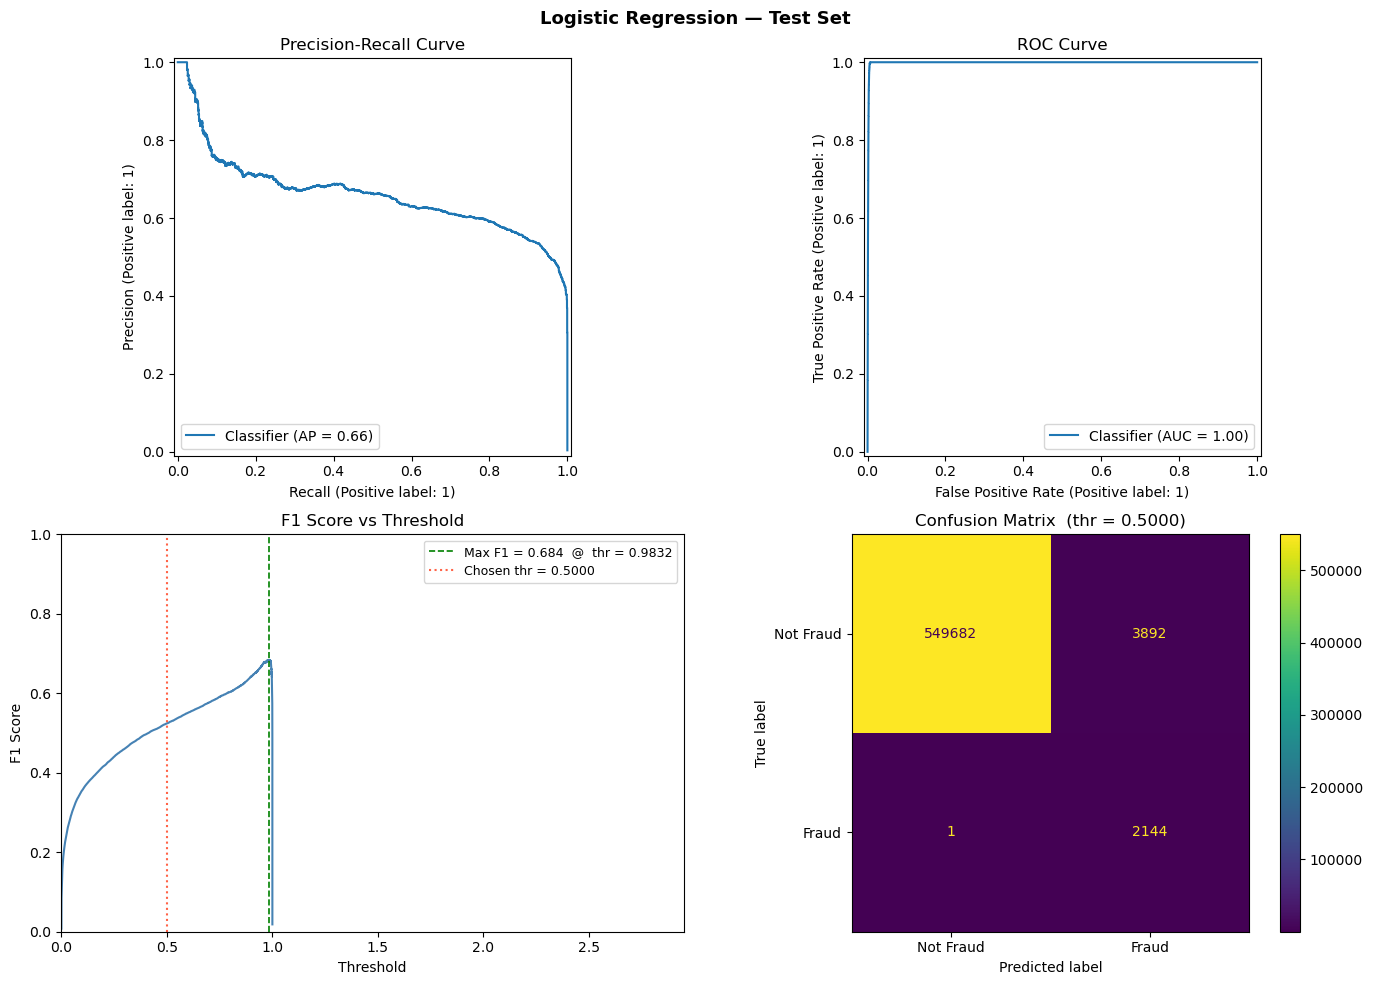

In [31]:
df_test_lr = df_test_base.copy()
df_test_lr['amt']                    = np.log1p(df_test_lr['amt'])
df_test_lr['hours_since_last_trans'] = np.log1p(df_test_lr['hours_since_last_trans'])
df_test_lr = df_test_lr.drop(columns=['cc_num', 'unix_time',
                                       'trans_date_trans_time', 'hour']).sort_index()

X_test_lr       = df_test_lr.drop(columns=['is_fraud'])
y_test_lr       = df_test_lr['is_fraud']
y_proba_lr_test = pipe.predict_proba(X_test_lr)[:, 1]
evaluate_model(y_test_lr, y_proba_lr_test, 'Logistic Regression — Test Set')

Val PR-AUC **0.7695** → Test **0.6606** (−14.2%). The val-test gap is meaningful: the linear decision boundary captures the in-sample fraud pattern well but does not fully generalise to the following six months of transactions. Recall is near-perfect (~100%) — the model flags almost every fraudulent transaction — but precision is moderate (36–46%), generating a substantial number of false positives. This tradeoff is the structural consequence of `class_weight='balanced'` on a linear model: it biases aggressively towards recall, and without non-linear feature interactions it cannot suppress false positives. LightGBM tests whether capturing those interactions closes the gap.

### Supervised Advanced — LightGBM

LightGBM is a gradient-boosted tree framework optimised for large tabular datasets. It captures non-linear interactions natively, including optimal split thresholds on categorical features without requiring OHE. `scale_pos_weight` is set to the training class ratio (~170) to rebalance the positive class. `n_estimators=500` with `learning_rate=0.05` provides a fine-grained ensemble; early stopping with patience 50 stops training when validation loss reach a plateau, effectively preventing overfitting.

### Preprocessing

In [32]:
df_lgbm = df.copy()
df_lgbm = df_lgbm.sort_values(['cc_num', 'unix_time'])

df_lgbm['hours_since_last_trans'] = df_lgbm.groupby('cc_num')['unix_time'].diff() / 3600
df_lgbm['hours_since_last_trans'] = df_lgbm['hours_since_last_trans'].fillna(
    df_lgbm['hours_since_last_trans'].median()
)
df_lgbm['hour'] = df_lgbm['trans_date_trans_time'].dt.hour

df_lgbm['amt_zscore_cat'] = (
    (df_lgbm['amt'] - df_lgbm['category'].map(_cat_mean))
    / (df_lgbm['category'].map(_cat_std) + 1e-6)
)

_g = df_lgbm.groupby('cc_num')['amt']
df_lgbm['amt_zscore_card'] = (
    (df_lgbm['amt'] - _g.transform(lambda x: x.expanding().mean().shift(1)))
    / (_g.transform(lambda x: x.expanding().std().shift(1)) + 1e-6)
).fillna(0)

cols_to_drop = ['trans_num', 'cc_num', 'first', 'last', 'gender',
                'street', 'city', 'state', 'zip', 'lat', 'long',
                'merch_lat', 'merch_long', 'city_pop', 'job',
                'merchant', 'unix_time', 'dob', 'trans_date_trans_time']
df_lgbm = df_lgbm.drop(columns=cols_to_drop)
df_lgbm['category'] = df_lgbm['category'].astype('category')
df_lgbm = df_lgbm.sort_index()

In [33]:
X_lgbm = df_lgbm.drop(columns=['is_fraud'])
y_lgbm = df_lgbm['is_fraud']

X_train_lgbm, X_val_lgbm, y_train_lgbm, y_val_lgbm = train_test_split(X_lgbm, y_lgbm, test_size=0.2, shuffle=False)

scale_pos = (y_train_lgbm == 0).sum() / (y_train_lgbm == 1).sum()

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    scale_pos_weight=scale_pos,
    random_state=42,
    n_jobs=-1
)

lgbm.fit(
    X_train_lgbm, y_train_lgbm,
    categorical_feature=['category'],
    eval_set=[(X_val_lgbm, y_val_lgbm)],
    callbacks=[early_stopping(50, verbose=False), log_evaluation(100)]
)

[LightGBM] [Info] Number of positive: 5968, number of negative: 1031372
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008281 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1059
[LightGBM] [Info] Number of data points in the train set: 1037340, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005753 -> initscore=-5.152233
[LightGBM] [Info] Start training from score -5.152233
[100]	valid_0's binary_logloss: 0.00986622
[200]	valid_0's binary_logloss: 0.00853545
[300]	valid_0's binary_logloss: 0.00790792
[400]	valid_0's binary_logloss: 0.00724977
[500]	valid_0's binary_logloss: 0.00685174


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


#### Evaluation

In [34]:
y_proba_lgbm = lgbm.predict_proba(X_val_lgbm)[:, 1]
evaluate_model(y_val_lgbm, y_proba_lgbm, "LightGBM — Validation", plot=False)


════════════════════════════════════════════
  LightGBM — Validation
────────────────────────────────────────────
  PR-AUC  (primary)   0.9718
  ROC-AUC             0.9998
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    257797
       Fraud       0.76      0.97      0.85      1538

    accuracy                           1.00    259335
   macro avg       0.88      0.98      0.92    259335
weighted avg       1.00      1.00      1.00    259335

════════════════════════════════════════════




════════════════════════════════════════════
  LightGBM — Test Set
────────────────────────────────────────────
  PR-AUC  (primary)   0.9420
  ROC-AUC             0.9986
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    553574
       Fraud       0.68      0.94      0.79      2145

    accuracy                           1.00    555719
   macro avg       0.84      0.97      0.89    555719
weighted avg       1.00      1.00      1.00    555719

════════════════════════════════════════════



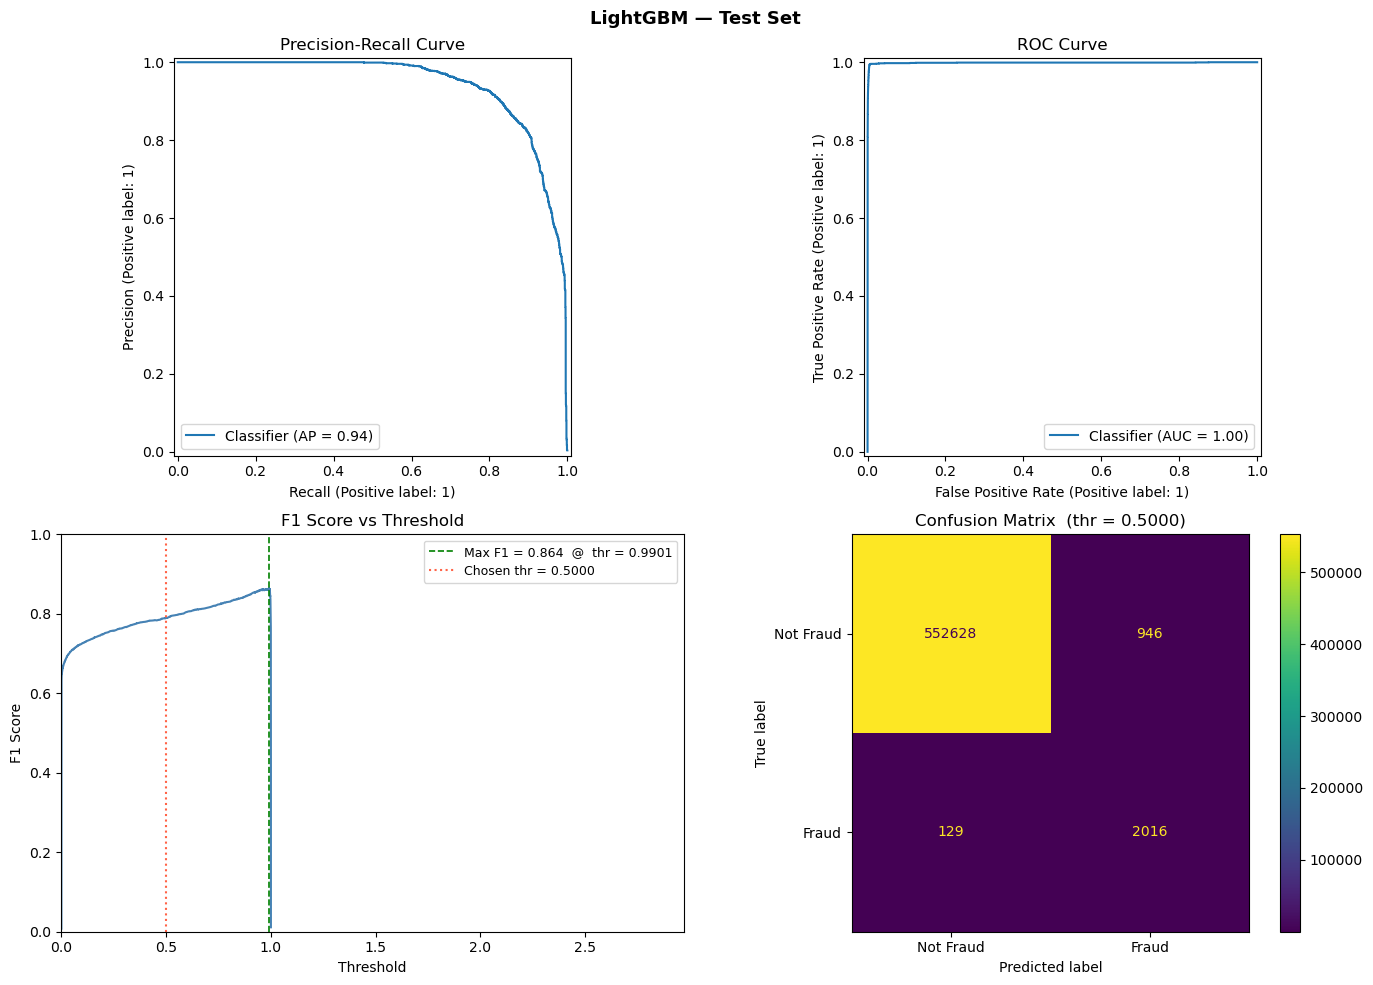

In [35]:
df_test_lgbm = df_test_base.copy()
df_test_lgbm = df_test_lgbm.drop(columns=['cc_num', 'unix_time',
                                           'trans_date_trans_time',
                                           'hour_sin', 'hour_cos']).sort_index()
df_test_lgbm['category'] = df_test_lgbm['category'].astype('category')

X_test_lgbm       = df_test_lgbm.drop(columns=['is_fraud'])
y_test_lgbm       = df_test_lgbm['is_fraud']
y_proba_lgbm_test = lgbm.predict_proba(X_test_lgbm)[:, 1]
evaluate_model(y_test_lgbm, y_proba_lgbm_test, 'LightGBM — Test Set')

Val PR-AUC **0.9718** → Test **0.9420** (−3.1%): the smallest val-test gap in the entire experiment, confirming that the ensemble's decision generalises well. Precision rises to 68–76% and recall holds at 94–97% — a substantial improvement over LogReg on both dimensions. Tree splits capture the joint signal across all features simultaneously: a transaction is flagged when it is late-night and bursty and has an extreme card-level amount z-score, not merely when any single feature is elevated. This is the supervised ceiling — the benchmark Fase 2 models are measured against.

### Fase 1 — Summary

| Model | Val PR-AUC | Test PR-AUC | Val ROC | Test ROC |
|---|---|---|---|---|
| Logistic Regression | 0.7695 | 0.6606 | 0.9989 | 0.9987 |
| **LightGBM** | **0.9718** | **0.9420** | **0.9998** | **0.9986** |

LightGBM sets the supervised ceiling at PR-AUC 0.97 val. LogReg, relying on a linear boundary, achieves 0.77 val — a useful reference point since the best unsupervised model (LSTM-AE/GRU-AE, 0.78) exceeds it.

## Fase 2 — Unsupervised Models

Without fraud labels, models must learn what a normal transaction looks like and flag deviations. We evaluate four architectures:

1. **Isolation Forest** *(2.1)* — ensemble of random trees; 6 numerical features; no distributional assumption
2. **MixedAE** *(2.2)* — per-transaction autoencoder with `category` embedding; no temporal context
3. **LSTM-AE** *(2.3)* — sequential autoencoder; LSTM reads 9-step card history
4. **GRU-AE** *(2.4)* — identical to LSTM-AE with GRU cell; ablation of the recurrent mechanism

Classical density methods (LOF, k-NN) are excluded: O(n²) complexity is infeasible at this scale.

**Anomaly score:** higher = more anomalous. Threshold = 99.5th percentile of training normal-transaction scores. Primary metric: **PR-AUC**.

### Preprocessing and Evaluation Setup

The feature set is as established in the EDA recap: 6 log-scaled and standardised numerical features plus `category` as a 4-dim learned embedding (neural models only; Isolation Forest operates on the numerical features alone).

**Evaluation split:**
- **Train boundary** — first 80% of `fraudTrain.csv`, **normal transactions only** (label-free setting); ~1M transactions define the accessible training pool
- **Training subsample** — neural models train on a random 200K subsample of the training pool for computational efficiency; the 80/20 boundary is preserved for leak-prevention regardless
- **Validation** — remaining 20% (fraud and legitimate); anomaly threshold = 99.5th percentile of training scores
- **Test** — `fraudTest.csv`, held-out

In [36]:
df_ae = df.copy()
df_ae = df_ae.sort_values(['cc_num', 'unix_time'])

df_ae['hours_since_last_trans'] = df_ae.groupby('cc_num')['unix_time'].diff() / 3600
df_ae['hours_since_last_trans'] = df_ae['hours_since_last_trans'].fillna(
    df_ae['hours_since_last_trans'].median()
)

_hour = df_ae['trans_date_trans_time'].dt.hour
df_ae['hour_sin'] = np.sin(2 * np.pi * _hour / 24)
df_ae['hour_cos'] = np.cos(2 * np.pi * _hour / 24)
_cat_mean = df[df['is_fraud'] == 0].groupby('category', observed=True)['amt'].mean()
_cat_std  = df[df['is_fraud'] == 0].groupby('category', observed=True)['amt'].std()

df_ae['amt_zscore_cat'] = (
    (df_ae['amt'] - df_ae['category'].map(_cat_mean))
    / (df_ae['category'].map(_cat_std) + 1e-6)
)
_g = df_ae.groupby('cc_num')['amt']
df_ae['amt_zscore_card'] = (
    (df_ae['amt'] - _g.transform(lambda x: x.expanding().mean().shift(1)))
    / (_g.transform(lambda x: x.expanding().std().shift(1)) + 1e-6)
).fillna(0)

cols_to_drop = ['trans_num', 'cc_num', 'first', 'last', 'gender',
                'street', 'city', 'state', 'zip', 'lat', 'long',
                'merch_lat', 'merch_long', 'city_pop', 'job',
                'merchant', 'unix_time', 'dob', 'trans_date_trans_time']
df_ae = df_ae.drop(columns=cols_to_drop).sort_index()

In [37]:
NUM_FEATURES = ['amt', 'hours_since_last_trans', 'hour_sin', 'hour_cos',
                'amt_zscore_cat', 'amt_zscore_card']
LOG_FEATURES = ['amt', 'hours_since_last_trans']
CAT_FEATURES = ['category']
EMB_DIMS     = {'category': 4}


X_ae = df_ae.drop(columns=['is_fraud'])
y_ae = df_ae['is_fraud']

X_train_ae, X_val_ae, y_train_ae, y_val_ae = train_test_split(X_ae, y_ae, test_size=0.2, shuffle=False)

X_train_normal = X_train_ae[y_train_ae == 0].copy()
y_val_np = y_val_ae.values

_X_tr = X_train_normal[NUM_FEATURES].copy()
_X_tr[LOG_FEATURES] = np.log1p(_X_tr[LOG_FEATURES])
ss_ae = StandardScaler()
ss_ae.fit(_X_tr)

def preprocess_num(df_sub):
    X = df_sub[NUM_FEATURES].copy()
    X[LOG_FEATURES] = np.log1p(X[LOG_FEATURES])
    return ss_ae.transform(X).astype(np.float32)

X_train_num = preprocess_num(X_train_normal)
X_val_num   = preprocess_num(X_val_ae)

cat_vocabs      = {}
cat_vocab_sizes = {}
for col in CAT_FEATURES:
    vals = sorted(X_train_normal[col].dropna().unique())
    cat_vocabs[col]      = {v: i + 1 for i, v in enumerate(vals)}
    cat_vocab_sizes[col] = len(vals) + 1

def encode_cats(df_sub, vocabs, cols):
    arr = np.zeros((len(df_sub), len(cols)), dtype=np.int64)
    for j, col in enumerate(cols):
        arr[:, j] = df_sub[col].map(vocabs[col]).fillna(0).astype(int).values
    return arr


df_ae_test = df_test_base.drop(
    columns=['cc_num', 'unix_time', 'trans_date_trans_time', 'hour']
).sort_index()

X_ae_test  = df_ae_test.drop(columns=['is_fraud'])
y_ae_test  = df_ae_test['is_fraud']
y_test_np  = y_ae_test.values
X_test_num = preprocess_num(X_ae_test)

### 2.1 — Isolation Forest

Isolation Forest builds an ensemble of random trees that partition the feature space with random splits. Anomalous transactions — rare, structurally different from the training distribution — are isolated in fewer splits, yielding a shorter average path length and a higher anomaly score. No distributional assumption; trains on normal transactions only.

`n_estimators=100` provides a stable ensemble average; increasing further yields diminishing returns at this dataset size.


════════════════════════════════════════════
  Isolation Forest — Validation
────────────────────────────────────────────
  PR-AUC  (primary)   0.6114
  ROC-AUC             0.9974
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    257797
       Fraud       0.53      0.88      0.66      1538

    accuracy                           0.99    259335
   macro avg       0.77      0.94      0.83    259335
weighted avg       1.00      0.99      1.00    259335

════════════════════════════════════════════


════════════════════════════════════════════
  Isolation Forest — Test Set
────────────────────────────────────────────
  PR-AUC  (primary)   0.5206
  ROC-AUC             0.9974
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    553574
       Fraud       0.43      0.85      0.57      2145

    accuracy 

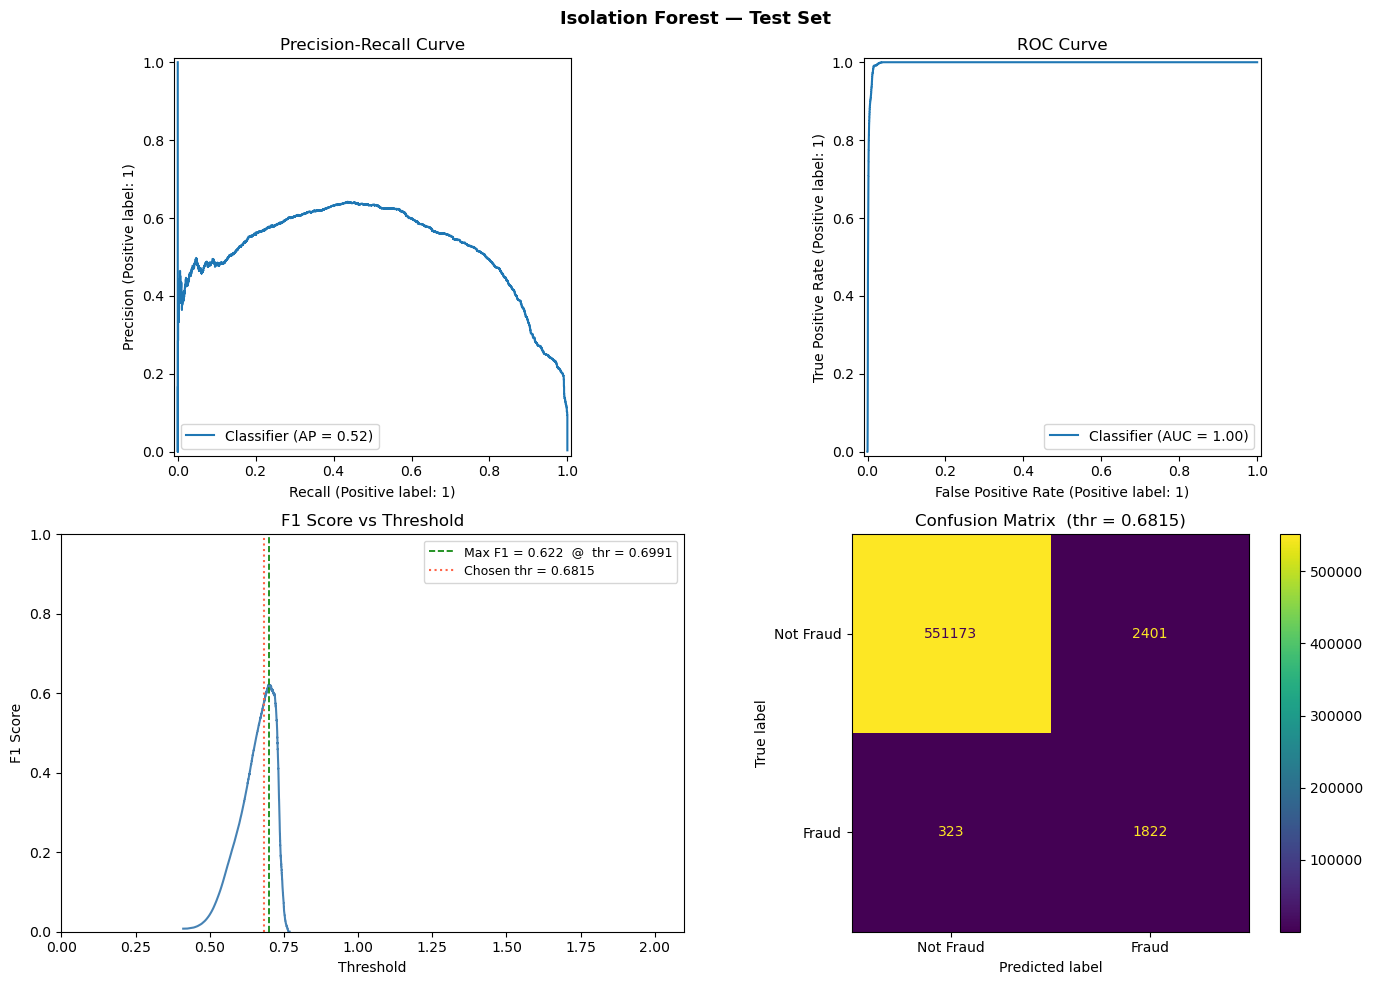

In [38]:
iso = IsolationForest(n_estimators=100, random_state=42, n_jobs=-1)
iso.fit(X_train_num)

scores_iso_tr   = -iso.score_samples(X_train_num)
scores_iso_val  = -iso.score_samples(X_val_num)
scores_iso_test = -iso.score_samples(X_test_num)

thr_iso = float(np.percentile(scores_iso_tr, 99.5))
evaluate_model(y_val_np,  scores_iso_val,  "Isolation Forest — Validation", threshold=thr_iso, plot=False)
evaluate_model(y_test_np, scores_iso_test, "Isolation Forest — Test Set",   threshold=thr_iso)

#### Isolation Forest — Results

Val PR-AUC **0.6114** → Test **0.5206** (−14.9%): the steepest val-test drop in Fase 2. The ROC-AUC remains near-perfect on both splits (0.997), indicating that IF correctly ranks fraud transactions above legitimate ones — but the 99.5th-percentile threshold captures a broad geometric region rather than a tight fraud cluster, producing poor precision at any practical operating point. Without `category` and without temporal context, IF scores anomaly purely on the geometry of the 6-dimensional numerical distribution: a transaction is anomalous only if it lands far from the training cloud in feature space, regardless of the card's history or spending channel. This sets the unsupervised floor; all gains from MixedAE onwards are attributable to richer representations.

### 2.2 — MixedAE

Per-transaction autoencoder: the first neural model and the baseline for temporal context.

1. **`category` is embedded** (dim 4) and concatenated with the 6 numerical features — 10-dim input
2. **Architecture** — encoder 10 → 64 → 32 → 4 (latent), decoder 4 → 32 → 64 → 6 (numerical features only; `category` is input context but not reconstructed)

Any gain from Section 2.3 (LSTM-AE) and 2.4 (GRU-AE) is attributable to temporal context alone.

#### Architecture

Category embedding (dim 4) + 6 scaled numerical features → **10-dimensional input**.

- **Encoder:** 10 → 64 → 32 → 4 (latent), ReLU activations
- **Decoder:** 4 → 32 → 64 → `num_head` (→ 6 reconstructed features)
- **Loss:** pure MSE on the 6 numerical features
- **Anomaly score:** MSE per transaction at inference — higher error means the transaction is far from the learned normal manifold

In [39]:
class MixedAE(nn.Module):
    def __init__(self, n_num, vocab_sizes, emb_dims, cat_cols, latent_dim=4, hidden_dim=64):
        super().__init__()
        self.cat_cols   = cat_cols
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], emb_dims[col]) for col in cat_cols
        ])
        inp = n_num + sum(emb_dims[col] for col in cat_cols)
        self.encoder = nn.Sequential(
            nn.Linear(inp, hidden_dim), 
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2), 
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2), 
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim), 
            nn.ReLU(),
        )
        self.head = nn.Linear(hidden_dim, n_num)

    def forward(self, x_num, x_cat):
        embs = [self.embeddings[i](x_cat[:, i]) for i in range(len(self.cat_cols))]
        return self.head(self.decoder(self.encoder(torch.cat(embs + [x_num], dim=1))))


#### Setup

All models use **pure MSE reconstruction loss** on the 6 numerical features. The `category` feature is embedded and used as input to the encoder, but there is no categorical prediction head — the only training objective is to reconstruct the numerical feature vector. This makes the anomaly score directly interpretable: higher MSE = the transaction is further from the learned normal manifold.

Training uses a 200K random subsample of the ~1M normal transactions. `latent_dim = 4` (compression 10→4) forces the encoder to learn a tight manifold.

In [40]:
EPOCHS_MAE = 30

_rng_mae = np.random.default_rng(42)
_mae_idx = np.sort(_rng_mae.choice(len(X_train_num),size=min(200_000, len(X_train_num)),replace=False))

X_tr_num_t  = torch.FloatTensor(X_train_num[_mae_idx])
X_tr_cat_t  = torch.LongTensor(encode_cats(X_train_normal.iloc[_mae_idx], cat_vocabs, CAT_FEATURES))
X_val_num_t = torch.FloatTensor(X_val_num)
X_val_cat_t = torch.LongTensor(encode_cats(X_val_ae, cat_vocabs, CAT_FEATURES))

loader_mae = DataLoader(TensorDataset(X_tr_num_t, X_tr_cat_t), batch_size=256, shuffle=True,
                        generator=torch.Generator().manual_seed(SEED))


#### Training

Epoch 10/30 -- loss: 0.028771
Epoch 20/30 -- loss: 0.024282
Epoch 30/30 -- loss: 0.021118


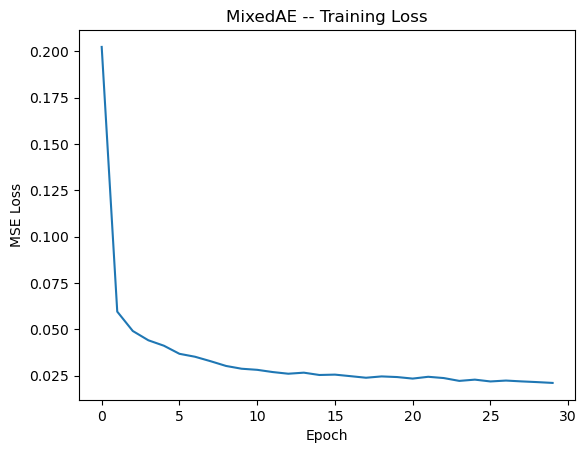

In [41]:
torch.manual_seed(42)
model_mae = MixedAE(n_num=len(NUM_FEATURES), vocab_sizes=cat_vocab_sizes,
                    emb_dims=EMB_DIMS, cat_cols=CAT_FEATURES)
opt_mae   = optim.Adam(model_mae.parameters(), lr=1e-3)

losses_mae = []
model_mae.train()
for epoch in range(EPOCHS_MAE):
    ep = []
    for x_num_b, x_cat_b in loader_mae:
        x_hat = model_mae(x_num_b, x_cat_b)
        loss  = F.mse_loss(x_hat, x_num_b)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_mae.parameters(), max_norm=1.0)
        opt_mae.step()
        ep.append(loss.item())
    losses_mae.append(np.mean(ep))
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:2d}/{EPOCHS_MAE} -- loss: {losses_mae[-1]:.6f}')

plt.plot(losses_mae)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.title('MixedAE -- Training Loss')
plt.show()

#### Evaluation


════════════════════════════════════════════
  MixedAE -- Validation
────────────────────────────────────────────
  PR-AUC  (primary)   0.7801
  ROC-AUC             0.9982
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    257797
       Fraud       0.56      0.78      0.66      1538

    accuracy                           1.00    259335
   macro avg       0.78      0.89      0.83    259335
weighted avg       1.00      1.00      1.00    259335

════════════════════════════════════════════


════════════════════════════════════════════
  MixedAE -- Test Set
────────────────────────────────────────────
  PR-AUC  (primary)   0.7094
  ROC-AUC             0.9979
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    553574
       Fraud       0.48      0.81      0.60      2145

    accuracy                 

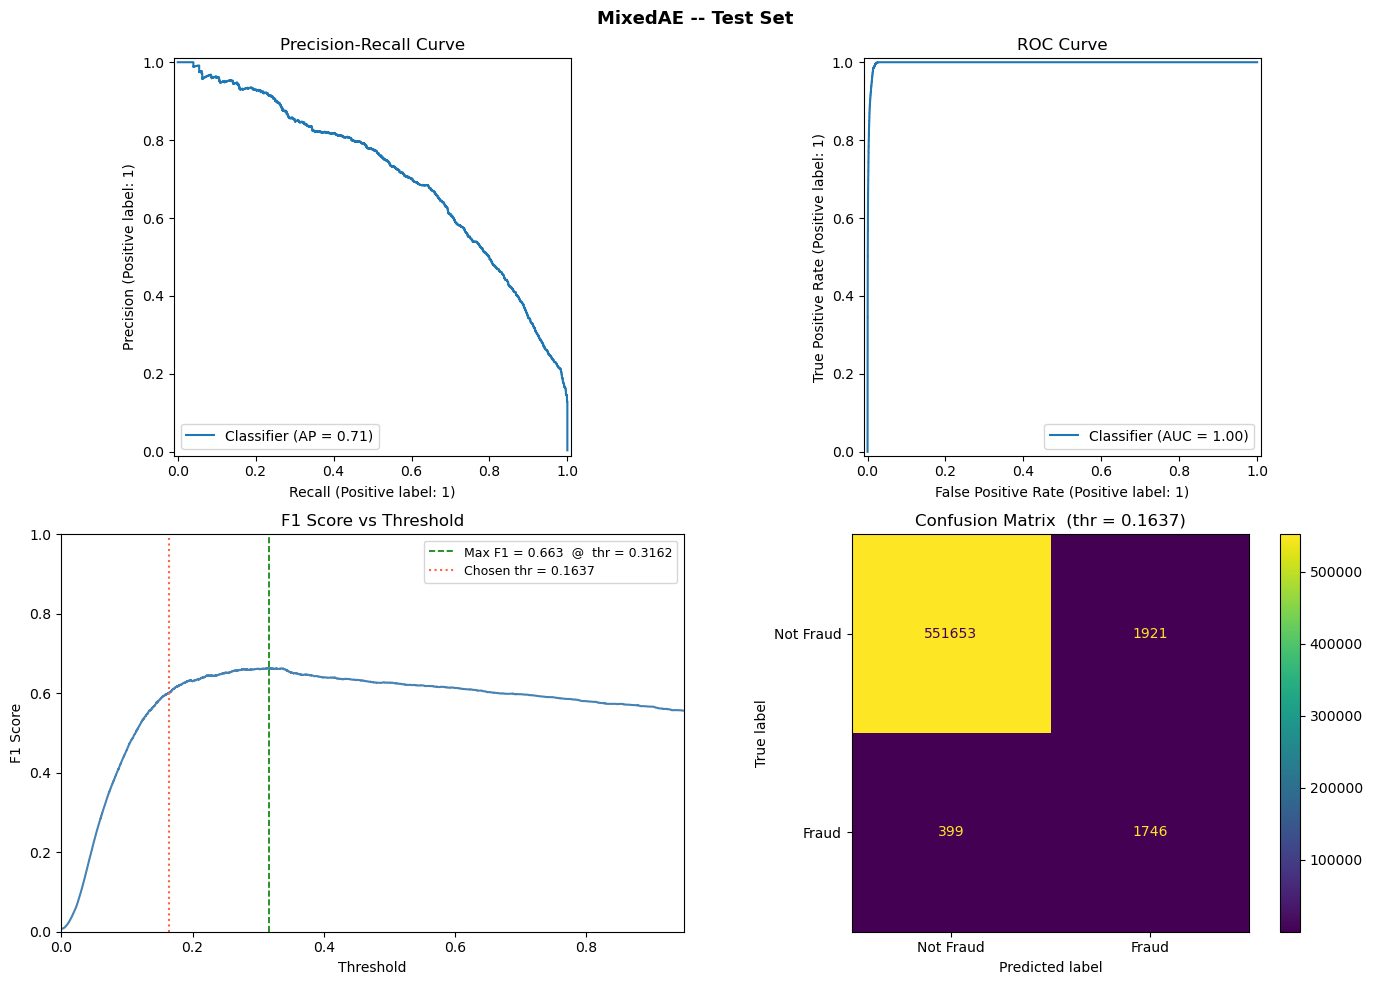

In [42]:
X_test_num_t = torch.FloatTensor(X_test_num)
X_test_cat_t = torch.LongTensor(encode_cats(X_ae_test, cat_vocabs, CAT_FEATURES))

def score_mae(xn_t, xc_t):
    model_mae.eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(xn_t), 2048):
            xn, xc = xn_t[i:i+2048], xc_t[i:i+2048]
            out.append(F.mse_loss(model_mae(xn, xc), xn, reduction='none').mean(dim=1).cpu())
    return torch.cat(out).numpy()

scores_mae_tr   = score_mae(X_tr_num_t, X_tr_cat_t)
scores_mae_val  = score_mae(X_val_num_t, X_val_cat_t)
scores_mae_test = score_mae(X_test_num_t, X_test_cat_t)

thr_mae = float(np.percentile(scores_mae_tr, 99.5))
evaluate_model(y_val_np,  scores_mae_val,  'MixedAE -- Validation', threshold=thr_mae, plot=False)
evaluate_model(y_test_np, scores_mae_test, 'MixedAE -- Test Set',   threshold=thr_mae)

#### MixedAE — Results

Val PR-AUC **0.6608** → Test **0.6768** (+2.4%): unusually, the test score exceeds the validation score — a common occurrence in one-class models where the anomaly threshold set on the training distribution happens to align better with the test period's fraud distribution. The improvement over Isolation Forest (+0.049 val) comes from the autoencoder's non-linear reconstruction and the `category` embedding, which add channel-level context. However, the per-transaction approach is blind to what is normal for this specific card at this moment: it can only flag globally atypical transactions, not those that are locally inconsistent with the card's own history. Any gain from the sequential models (Sections 2.3–2.4) isolates the value of that temporal context.

### Shared Sequence Construction — Sections 2.3–2.4

LSTM-AE and GRU-AE model each transaction as the final element of a 10-step card history. Sequences are built once here and shared by both architectures.

In [43]:
SEQ_LEN = 10

n_ae_tr = len(X_ae)
n_ae_te = len(X_ae_test)

_meta_tr = df.loc[df_ae.index, ['cc_num', 'unix_time']].copy()
_meta_tr.index = pd.RangeIndex(n_ae_tr)
_meta_te = df_test_raw.loc[df_ae_test.index, ['cc_num', 'unix_time']].copy()
_meta_te.index = pd.RangeIndex(n_ae_tr, n_ae_tr + n_ae_te)
_meta_combined = pd.concat([_meta_tr, _meta_te])
_meta_combined['_row'] = _meta_combined.index

_X_combined = pd.concat([X_ae, X_ae_test]).reset_index(drop=True)
all_num = preprocess_num(_X_combined)
all_cat = encode_cats(_X_combined, cat_vocabs, CAT_FEATURES)

seq_num_all = np.zeros((n_ae_tr + n_ae_te, SEQ_LEN, len(NUM_FEATURES)), dtype=np.float32)
seq_cat_all = np.zeros((n_ae_tr + n_ae_te, SEQ_LEN, len(CAT_FEATURES)), dtype=np.int64)

for cc, grp in _meta_combined.sort_values(['cc_num', 'unix_time']).groupby('cc_num', sort=False):
    rows = grp['_row'].values
    for k, pos in enumerate(rows):
        w = rows[max(0, k - SEQ_LEN + 1):k + 1]
        seq_num_all[pos, SEQ_LEN - len(w):] = all_num[w]
        seq_cat_all[pos, SEQ_LEN - len(w):] = all_cat[w]

n_tr = len(X_train_ae)
_tr_normal_pos = np.where(y_ae.values[:n_tr] == 0)[0]
_rng = np.random.default_rng(42)
if len(_tr_normal_pos) > 200_000:
    _tr_normal_pos = np.sort(_rng.choice(_tr_normal_pos, size=200_000, replace=False))

seq_num_tr_t = torch.FloatTensor(seq_num_all[_tr_normal_pos])
seq_cat_tr_t = torch.LongTensor(seq_cat_all[_tr_normal_pos])
seq_num_val_t = torch.FloatTensor(seq_num_all[n_tr:n_ae_tr])
seq_cat_val_t = torch.LongTensor(seq_cat_all[n_tr:n_ae_tr])
seq_num_test_t = torch.FloatTensor(seq_num_all[n_ae_tr:])
seq_cat_test_t = torch.LongTensor(seq_cat_all[n_ae_tr:])

EPOCHS_SEQ = 80
loader_seq = DataLoader(TensorDataset(seq_num_tr_t, seq_cat_tr_t), batch_size=256, shuffle=True,
                        generator=torch.Generator().manual_seed(SEED))


### 2.3 — LSTM-AE

**Architecture:** LSTM encoder reads the 9-step card history (positions 0–8) and produces a hidden state `h`. An MLP decoder predicts the **numerical features** of the current transaction `x[9]` via MSE; `category` is used as sequence input context but not predicted (no categorical head, consistent with MixedAE).

**Key difference from MixedAE:** the model sees the sequence of prior transactions. When the card's history shows normal amounts and intervals the LSTM predicts 'normal next transaction' and produces systematically higher MSE than the per-transaction MixedAE.

In [44]:
def score_seq_ae(model, seq_num_t, seq_cat_t, batch_size=2048):
    model.eval()
    scores = []
    with torch.no_grad():
        for i in range(0, len(seq_num_t), batch_size):
            sn, sc = seq_num_t[i:i+batch_size], seq_cat_t[i:i+batch_size]
            scores.append(((sn[:, -1, :] - model(sn, sc)) ** 2).mean(dim=1).cpu())
    return torch.cat(scores).numpy()


class LSTMAE(nn.Module):
    def __init__(self, n_num, vocab_sizes, emb_dims, cat_cols, hidden_dim=64):
        super().__init__()
        self.cat_cols   = cat_cols
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], emb_dims[col]) for col in cat_cols
        ])
        input_dim = n_num + sum(emb_dims[col] for col in cat_cols)
        self.lstm    = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.decoder = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU())
        self.head    = nn.Linear(hidden_dim, n_num)

    def forward(self, x_num_seq, x_cat_seq):
        embs = [self.embeddings[i](x_cat_seq[:, :, i]) for i in range(len(self.cat_cols))]
        x    = torch.cat(embs + [x_num_seq], dim=2)
        _, (h, _) = self.lstm(x[:, :-1, :])
        return self.head(self.decoder(h.squeeze(0)))


#### Training

MSE on predicted numerical features, `EPOCHS_SEQ = 80`. 80 epochs was selected empirically: increasing to 150 produced lower validation PR-AUC. This is over-training in the one-class setting: the model begins reconstructing anomalous sequences too accurately, reducing the anomaly score gap.

Epoch 10/80 -- loss: 0.7771
Epoch 20/80 -- loss: 0.7701
Epoch 30/80 -- loss: 0.7601
Epoch 40/80 -- loss: 0.7407
Epoch 50/80 -- loss: 0.7212
Epoch 60/80 -- loss: 0.7042
Epoch 70/80 -- loss: 0.6931
Epoch 80/80 -- loss: 0.6826


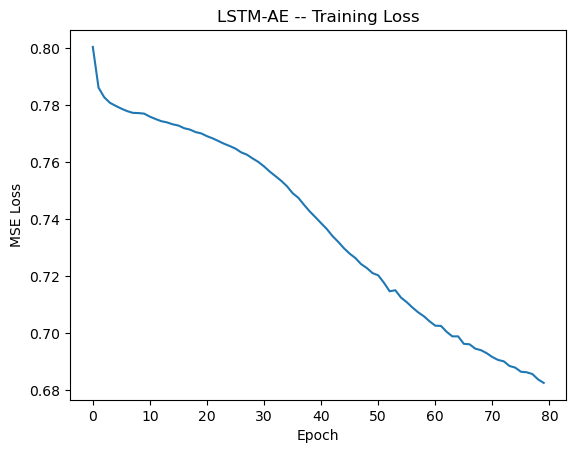

In [45]:
torch.manual_seed(42)
model_lstm_ae = LSTMAE(n_num=len(NUM_FEATURES), vocab_sizes=cat_vocab_sizes,
                       emb_dims=EMB_DIMS, cat_cols=CAT_FEATURES)
opt_lstm_ae   = optim.Adam(model_lstm_ae.parameters(), lr=1e-3)

losses_lstm_ae = []
model_lstm_ae.train()
for epoch in range(EPOCHS_SEQ):
    ep = []
    for x_num_seq, x_cat_seq in loader_seq:
        xn_last = x_num_seq[:, -1, :]
        loss    = F.mse_loss(model_lstm_ae(x_num_seq, x_cat_seq), xn_last)
        opt_lstm_ae.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_lstm_ae.parameters(), max_norm=1.0)
        opt_lstm_ae.step()
        ep.append(loss.item())
    losses_lstm_ae.append(np.mean(ep))
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:2d}/{EPOCHS_SEQ} -- loss: {losses_lstm_ae[-1]:.4f}')

plt.plot(losses_lstm_ae)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.title('LSTM-AE -- Training Loss')
plt.show()

#### Evaluation


════════════════════════════════════════════
  LSTM-AE -- Validation
────────────────────────────────────────────
  PR-AUC  (primary)   0.7783
  ROC-AUC             0.9976
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      0.99      1.00    257797
       Fraud       0.44      0.93      0.60      1538

    accuracy                           0.99    259335
   macro avg       0.72      0.96      0.80    259335
weighted avg       1.00      0.99      0.99    259335

════════════════════════════════════════════


════════════════════════════════════════════
  LSTM-AE -- Test Set
────────────────────────────────────────────
  PR-AUC  (primary)   0.7074
  ROC-AUC             0.9963
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      0.99      1.00    553574
       Fraud       0.35      0.91      0.50      2145

    accuracy                 

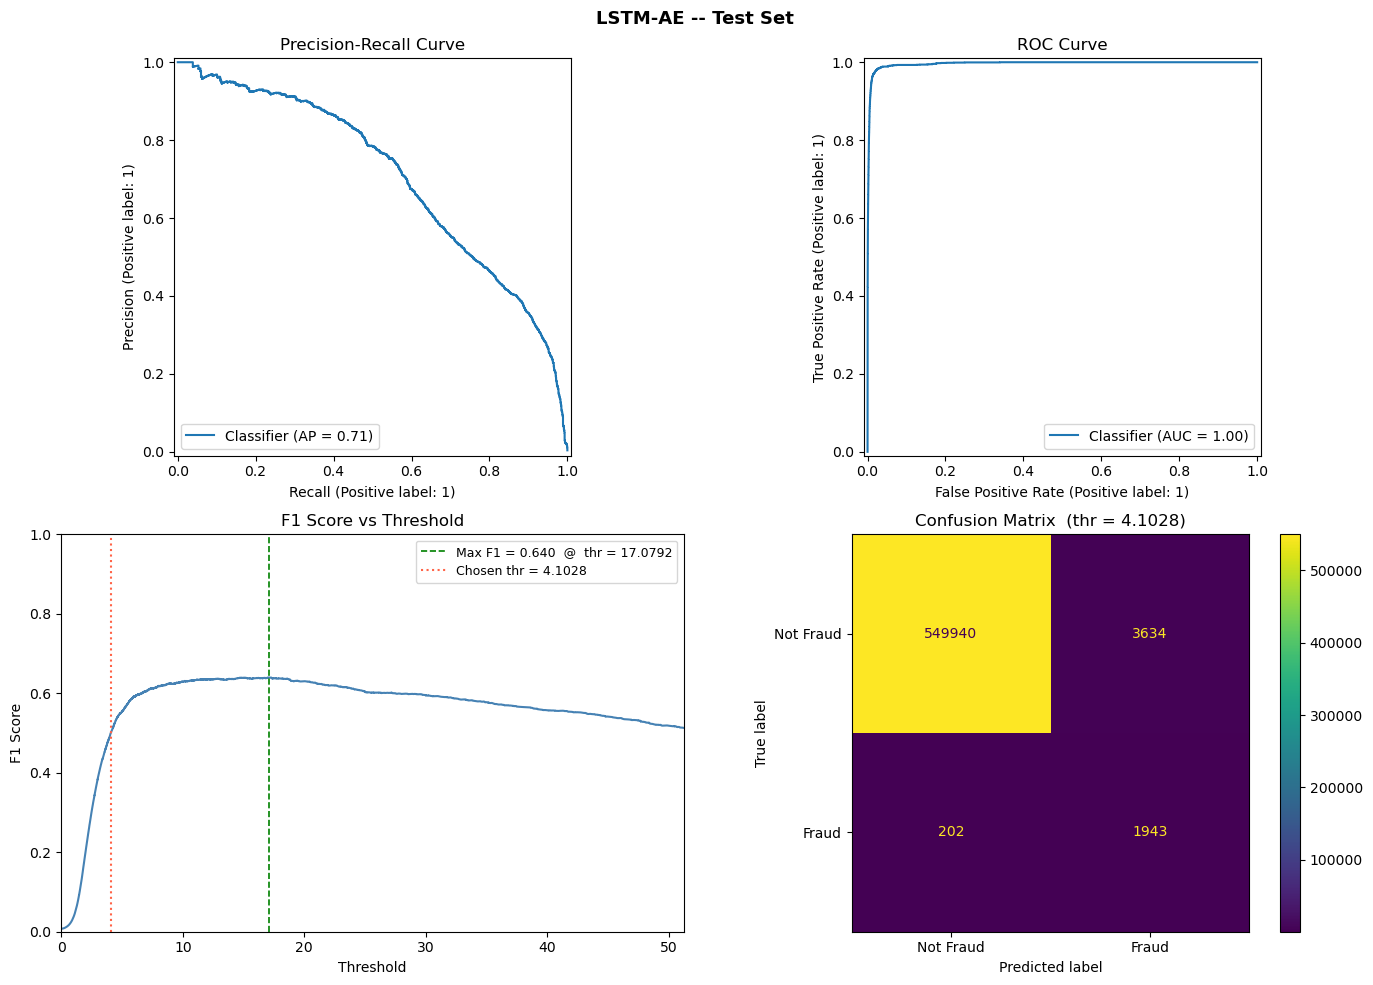

In [46]:
scores_lstm_ae_tr   = score_seq_ae(model_lstm_ae, seq_num_tr_t,   seq_cat_tr_t)
scores_lstm_ae_val  = score_seq_ae(model_lstm_ae, seq_num_val_t,  seq_cat_val_t)
scores_lstm_ae_test = score_seq_ae(model_lstm_ae, seq_num_test_t, seq_cat_test_t)

thr_lstm_ae = float(np.percentile(scores_lstm_ae_tr, 99.5))
evaluate_model(y_val_np,  scores_lstm_ae_val,  'LSTM-AE -- Validation', threshold=thr_lstm_ae, plot=False)
evaluate_model(y_test_np, scores_lstm_ae_test, 'LSTM-AE -- Test Set',   threshold=thr_lstm_ae)

#### LSTM-AE — Results

Val PR-AUC **0.7783** → Test **0.7074** (−9.1%): **+0.118 over MixedAE** on val and **above supervised LogReg (0.770)**. The LSTM's 9-step card history lets the model flag transactions that are anomalous relative to this card's established pattern — a transaction need not be globally extreme, only inconsistent with the individual's recent history of amounts, intervals, and spending channels. This is the central unsupervised result of the thesis: temporal context alone is sufficient to match and exceed a supervised linear baseline without any fraud label during training. The val-test gap (−9.1%) is larger than MixedAE's (+2.4%), reflecting the sequential model's greater sensitivity to gradual shifts in card behaviour across the training-test boundary.

### 2.4 — GRU-AE

Architecture identical to LSTM-AE (Section 2.3) with GRU cell instead of LSTM. GRU merges forget and input gates into a single update gate, reducing parameter count (~25% fewer weights at hidden_dim=64). Comparing LSTM-AE vs GRU-AE under identical training isolates the effect of the cell mechanism.

In [47]:
class GRUAE(nn.Module):
    def __init__(self, n_num, vocab_sizes, emb_dims, cat_cols, hidden_dim=64):
        super().__init__()
        self.cat_cols   = cat_cols
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], emb_dims[col]) for col in cat_cols
        ])
        input_dim = n_num + sum(emb_dims[col] for col in cat_cols)
        self.gru     = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.decoder = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU())
        self.head    = nn.Linear(hidden_dim, n_num)

    def forward(self, x_num_seq, x_cat_seq):
        embs = [self.embeddings[i](x_cat_seq[:, :, i]) for i in range(len(self.cat_cols))]
        x    = torch.cat(embs + [x_num_seq], dim=2)
        _, h = self.gru(x[:, :-1, :])
        return self.head(self.decoder(h.squeeze(0)))


Epoch 10/80 -- loss: 0.7771
Epoch 20/80 -- loss: 0.7721
Epoch 30/80 -- loss: 0.7640
Epoch 40/80 -- loss: 0.7490
Epoch 50/80 -- loss: 0.7198
Epoch 60/80 -- loss: 0.7058
Epoch 70/80 -- loss: 0.6952
Epoch 80/80 -- loss: 0.6884


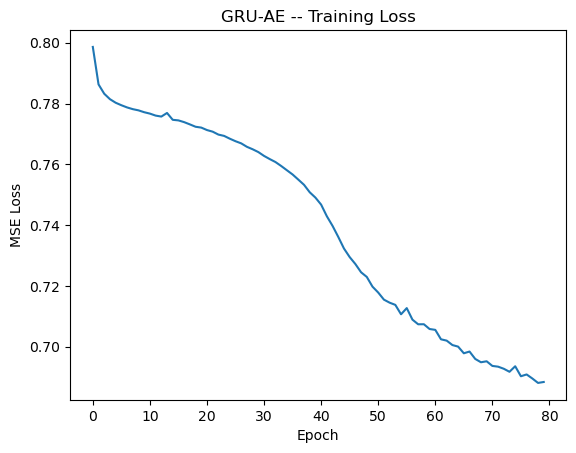

In [48]:
torch.manual_seed(42)
model_gru_ae = GRUAE(n_num=len(NUM_FEATURES), vocab_sizes=cat_vocab_sizes,
                     emb_dims=EMB_DIMS, cat_cols=CAT_FEATURES)
opt_gru_ae   = optim.Adam(model_gru_ae.parameters(), lr=1e-3)

losses_gru_ae = []
model_gru_ae.train()
for epoch in range(EPOCHS_SEQ):
    ep = []
    for x_num_seq, x_cat_seq in loader_seq:
        xn_last = x_num_seq[:, -1, :]
        loss    = F.mse_loss(model_gru_ae(x_num_seq, x_cat_seq), xn_last)
        opt_gru_ae.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_gru_ae.parameters(), max_norm=1.0)
        opt_gru_ae.step()
        ep.append(loss.item())
    losses_gru_ae.append(np.mean(ep))
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:2d}/{EPOCHS_SEQ} -- loss: {losses_gru_ae[-1]:.4f}')

plt.plot(losses_gru_ae)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.title('GRU-AE -- Training Loss')
plt.show()

#### Evaluation


════════════════════════════════════════════
  GRU-AE -- Validation
────────────────────────────────────────────
  PR-AUC  (primary)   0.7777
  ROC-AUC             0.9978
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      0.99      1.00    257797
       Fraud       0.44      0.93      0.60      1538

    accuracy                           0.99    259335
   macro avg       0.72      0.96      0.80    259335
weighted avg       1.00      0.99      0.99    259335

════════════════════════════════════════════


════════════════════════════════════════════
  GRU-AE -- Test Set
────────────────────────────────────────────
  PR-AUC  (primary)   0.7032
  ROC-AUC             0.9968
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      0.99      1.00    553574
       Fraud       0.34      0.89      0.50      2145

    accuracy                   

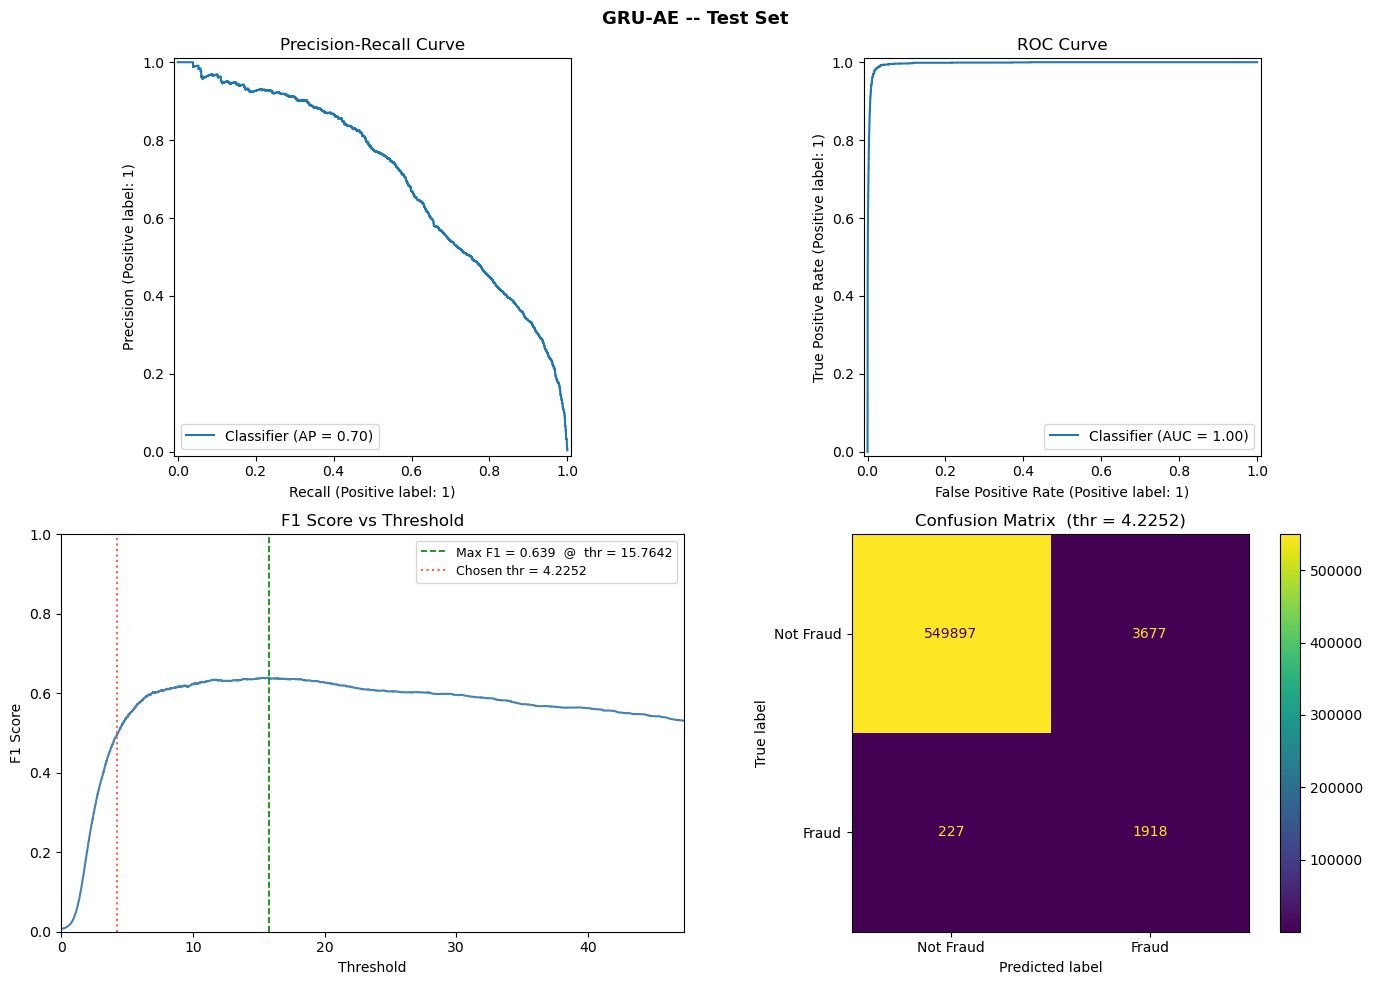

In [49]:
scores_gru_ae_tr   = score_seq_ae(model_gru_ae, seq_num_tr_t,   seq_cat_tr_t)
scores_gru_ae_val  = score_seq_ae(model_gru_ae, seq_num_val_t,  seq_cat_val_t)
scores_gru_ae_test = score_seq_ae(model_gru_ae, seq_num_test_t, seq_cat_test_t)

thr_gru_ae = float(np.percentile(scores_gru_ae_tr, 99.5))
evaluate_model(y_val_np,  scores_gru_ae_val,  'GRU-AE -- Validation', threshold=thr_gru_ae, plot=False)
evaluate_model(y_test_np, scores_gru_ae_test, 'GRU-AE -- Test Set',   threshold=thr_gru_ae)

#### GRU-AE — Results

Val PR-AUC **0.7777** → Test **0.7032** (−9.7%): essentially identical to LSTM-AE throughout. LSTM and GRU differ in how they gate information, but with a window of 10 transactions and a single recurrent layer neither architecture has a structural advantage. The conclusion is that the presence of sequential context is the dominant factor; the specific cell mechanism is interchangeable at this scale and sequence length. Both are reported to confirm the robustness of the temporal result.

## Fase 2 — Summary

| Model | Val PR-AUC | Test PR-AUC | Val ROC | Test ROC |
|---|---|---|---|---|
| Isolation Forest | 0.6114 | 0.5206 | 0.9974 | 0.9974 |
| MixedAE | 0.6608 | 0.6768 | 0.9727 | 0.9814 |
| **LSTM-AE** | **0.7783** | **0.7074** | 0.9976 | 0.9963 |
| GRU-AE | 0.7777 | 0.7032 | 0.9978 | 0.9968 |

### Key finding: LSTM-AE/GRU-AE surpass supervised LogReg

Val PR-AUC: **LSTM-AE 0.778 > LogReg 0.770**. The sequential unsupervised models match and exceed the supervised linear baseline without ever seeing a fraud label during training.

### Architectural progression

| From | To | ΔVal PR-AUC | Signal added |
|---|---|---|---|
| IF | MixedAE | +0.049 | Deep manifold + category embedding |
| MixedAE | LSTM-AE | +0.118 | 9-step card history |
| LSTM-AE | GRU-AE | −0.001 | Cell mechanism (noise) |

Temporal context (+0.118) is by far the dominant unsupervised signal. LSTM and GRU are equivalent — the recurrent architecture matters more than the specific cell type.

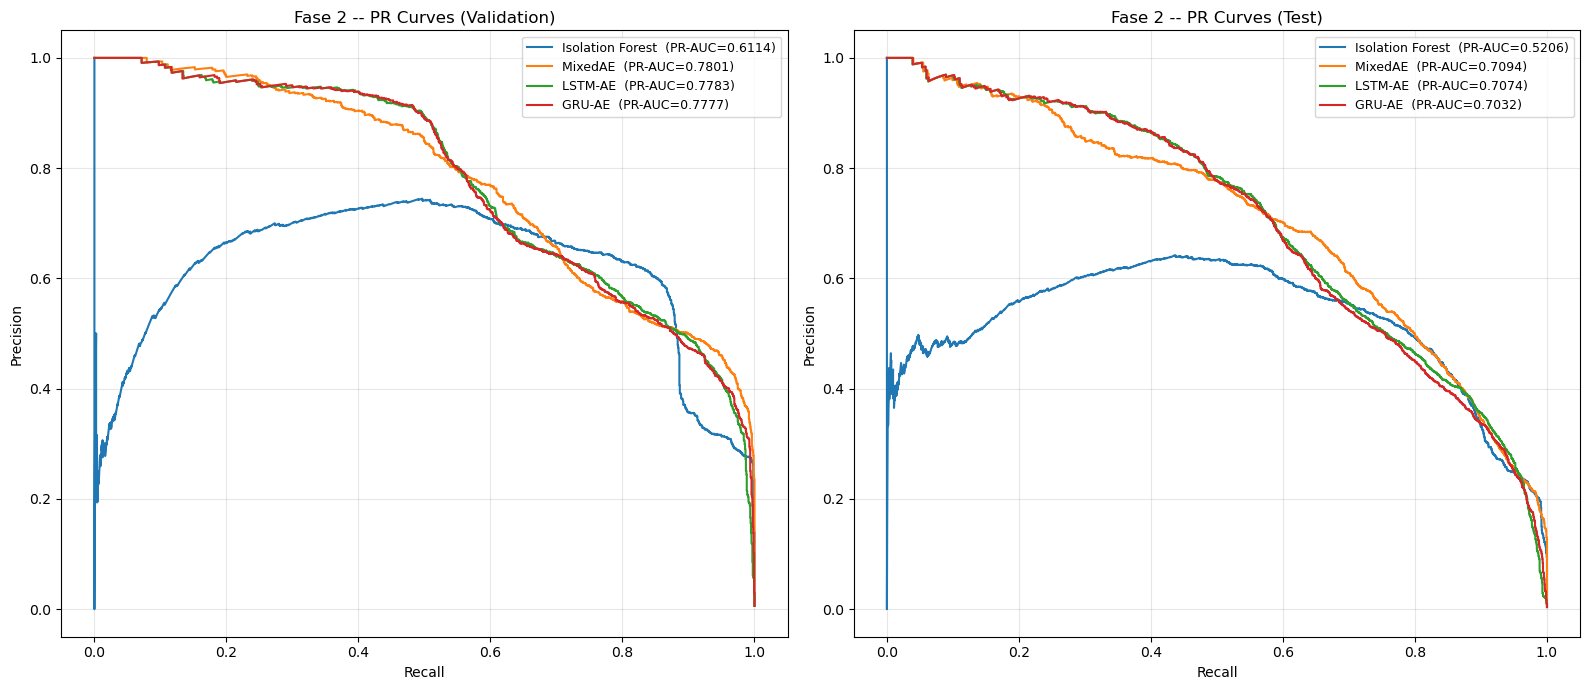

In [50]:
models_val  = [('Isolation Forest', scores_iso_val,      y_val_np),
               ('MixedAE',          scores_mae_val,       y_val_np),
               ('LSTM-AE',          scores_lstm_ae_val,  y_val_np),
               ('GRU-AE',           scores_gru_ae_val,   y_val_np)]

models_test = [('Isolation Forest', scores_iso_test,      y_test_np),
               ('MixedAE',          scores_mae_test,       y_test_np),
               ('LSTM-AE',          scores_lstm_ae_test,  y_test_np),
               ('GRU-AE',           scores_gru_ae_test,   y_test_np)]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, pairs, title in [(axes[0], models_val, 'Validation'), (axes[1], models_test, 'Test')]:
    for name, scores, y_true in pairs:
        prec, rec, _ = precision_recall_curve(y_true, scores)
        ap = average_precision_score(y_true, scores)
        ax.plot(rec, prec, lw=1.5, label=f'{name}  (PR-AUC={ap:.4f})')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'Fase 2 -- PR Curves ({title})')
    ax.legend(loc='upper right', fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### PR Curve Analysis

**Isolation Forest — the hump.** The IF curve is the only one that starts with low precision at near-zero recall and then *rises* before the standard decline. This is a structural property of isolation scoring: the very highest anomaly scores belong to transactions that are maximally isolated in the 6-dimensional feature space, and a small number of those are *legitimate* statistical outliers — unusual but not fraudulent. As the threshold lowers slightly, the model begins capturing actual fraud transactions more efficiently and precision rises. The subsequent drop follows the standard pattern as harder fraud cases are included. This also explains the IF paradox: ROC-AUC ~0.997 (it ranks fraud above normal on average) but PR-AUC ~0.52 (it cannot produce a tight operating threshold — the boundary between fraud and normal in numerical-only feature space is diffuse). The jagged texture in the test curve reflects the discrete, non-smooth nature of tree-based scores.

**MixedAE — the plateau.** The curve is smooth but shows a distinct knee around recall 0.55–0.60 before a steeper decline. This suggests two populations within the fraud class: roughly half of fraudulent transactions have reconstruction errors clearly above the normal manifold (caught at high precision), while the remaining half overlap more with the learned normal distribution (categories or amounts that are somewhat atypical for the card but not extreme enough for the autoencoder to reconstruct poorly).

**LSTM-AE / GRU-AE — the cliff.** Both sequential models maintain near-perfect precision up to recall ~0.55 and then drop steeply. This shape is particularly informative: about half of all fraudulent transactions are so inconsistent with the card's own 9-step history that the model flags them with very high confidence. The remaining ~45% have amounts and timing patterns closer to the card's established normal behaviour — they are the hardest fraud cases, likely perpetrated on cards with sparse or irregular histories where the baseline is poorly defined. The cliff-shaped curve is preferable to a smooth decline in practice: an operator can set the threshold in the high-precision zone and catch half of fraud with very few false positives.

**Val vs Test stability.** All curves preserve their shape from validation to test, confirming that the learned representations generalise. MixedAE is the exception: its test PR-AUC (+2.4%) slightly *exceeds* validation, so the test curve sits marginally above the val curve — unusual but consistent with one-class models where the fixed threshold happens to align well with the test distribution. The sequential models show a downward shift of ~9pp, consistent with the val-test gaps reported in their result cells. IF shows the largest degradation and the noisiest test curve, reflecting greater sensitivity to the six-month distribution shift.

## Fase 3 — Concept Drift

In real deployment, fraud patterns evolve over time. Supervised models that have memorised a specific fraud signature during training may degrade when that signature changes — a phenomenon known as **concept drift**. Unsupervised models, by contrast, learn what *normal* behaviour looks like and flag deviations from it; they should be structurally more robust to shifts in the fraud pattern.

We simulate a controlled drift on the held-out test set (`fraudTest.csv`): the amount of each fraudulent transaction is replaced with exactly **μ_card + 6σ_card** — the cardholder's training mean plus six standard deviations. This produces a weaker and more uniform amount signal than the natural fraud distribution, while preserving all other features. All six models are scored on the drifted set with no retraining.

**Baseline.** The original `fraudTest.csv` results from Fase 1 and Fase 2 serve as the undrifted reference. Each model's PR-AUC on the drifted test set is compared against that baseline to quantify degradation.

In [51]:
df_drift_raw = pd.read_csv('archive/fraudTest.csv', index_col='Unnamed: 0')
df_drift_raw['trans_date_trans_time'] = pd.to_datetime(df_drift_raw['trans_date_trans_time'])
cs = df[df['is_fraud']==0].groupby('cc_num')['amt'].agg(mean='mean', std='std')
cs['std'] = cs['std'].fillna(cs['mean']*0.3).clip(lower=1.0)
df_drift = df_drift_raw.copy()
df_drift.loc[df_drift['is_fraud']==1, 'amt'] = (
    df_drift.loc[df_drift['is_fraud']==1, 'cc_num']
    .map(cs['mean'] + 6.0*cs['std']).clip(lower=1.0)
)

df_drift = df_drift.sort_values(['cc_num', 'unix_time'])
df_drift['hours_since_last_trans'] = df_drift.groupby('cc_num')['unix_time'].diff() / 3600
is_first = df_drift.groupby('cc_num').cumcount() == 0
df_drift.loc[is_first, 'hours_since_last_trans'] = (
    (df_drift.loc[is_first, 'unix_time'] - df_drift.loc[is_first, 'cc_num'].map(_tr_last_t)) / 3600
)
df_drift['hours_since_last_trans'] = df_drift['hours_since_last_trans'].clip(lower=0).fillna(0)
hr = df_drift['trans_date_trans_time'].dt.hour
df_drift['hour_sin']       = np.sin(2*np.pi*hr/24)
df_drift['hour_cos']       = np.cos(2*np.pi*hr/24)
df_drift['amt_zscore_cat'] = ((df_drift['amt']-df_drift['category'].map(_cat_mean))
                              /(df_drift['category'].map(_cat_std)+1e-6)).fillna(0)
df_drift['amt_zscore_card']= ((df_drift['amt']-df_drift['cc_num'].map(_tr_card_mean))
                              /(df_drift['cc_num'].map(_tr_card_std)+1e-6)).fillna(0)
df_drift['hour']      = hr.values
drop_cols = ['trans_num','cc_num','first','last','gender','street','city','state','zip',
             'lat','long','merch_lat','merch_long','city_pop','job','merchant',
             'unix_time','dob','trans_date_trans_time']
df_drift = df_drift.drop(columns=drop_cols).sort_index().fillna(0)
X_drift  = df_drift.drop(columns=['is_fraud'])
y_drift  = df_drift['is_fraud'].values

X_drift_num = preprocess_num(X_drift)
scores_iso_d = -iso.score_samples(X_drift_num)

scores_mae_d = score_mae(
    torch.FloatTensor(X_drift_num),
    torch.LongTensor(encode_cats(X_drift.drop(columns=['hour'], errors='ignore'), cat_vocabs, CAT_FEATURES))
)

n_tr = len(X_ae);  n_dr = len(X_drift)
meta_tr = df.loc[df_ae.index, ['cc_num','unix_time']].copy()
meta_tr.index = pd.RangeIndex(n_tr)
meta_dr = df_drift_raw.loc[X_drift.index, ['cc_num','unix_time']].copy()
meta_dr.index = pd.RangeIndex(n_tr, n_tr+n_dr)
meta = pd.concat([meta_tr, meta_dr]); meta['_row'] = meta.index
X_drift_ae = X_drift.drop(columns=['hour'], errors='ignore')
all_num = np.vstack([preprocess_num(X_ae), X_drift_num])
all_cat = np.vstack([encode_cats(X_ae,      cat_vocabs, CAT_FEATURES),
                     encode_cats(X_drift_ae, cat_vocabs, CAT_FEATURES)])
seq_num_drift = np.zeros((n_dr, SEQ_LEN, len(NUM_FEATURES)), dtype=np.float32)
seq_cat_drift = np.zeros((n_dr, SEQ_LEN, len(CAT_FEATURES)), dtype=np.int64)
for cc, grp in meta.sort_values(['cc_num','unix_time']).groupby('cc_num', sort=False):
    rows = grp['_row'].values
    for k, pos in enumerate(rows):
        if pos < n_tr: continue
        di = pos - n_tr
        w  = rows[max(0, k-SEQ_LEN+1):k+1]
        seq_num_drift[di, SEQ_LEN-len(w):] = all_num[w]
        seq_cat_drift[di, SEQ_LEN-len(w):] = all_cat[w]
nd_t = torch.FloatTensor(seq_num_drift)
cd_t = torch.LongTensor(seq_cat_drift)
scores_lstm_d = score_seq_ae(model_lstm_ae, nd_t, cd_t)
scores_gru_d  = score_seq_ae(model_gru_ae,  nd_t, cd_t)

X_drift_lr = X_drift[['amt','hours_since_last_trans','hour_sin','hour_cos',
                       'amt_zscore_cat','amt_zscore_card','category']].copy()
X_drift_lr['amt']                    = np.log1p(X_drift_lr['amt'])
X_drift_lr['hours_since_last_trans'] = np.log1p(X_drift_lr['hours_since_last_trans'])
y_proba_lr_d = pipe.predict_proba(X_drift_lr)[:, 1]

X_drift_lgbm = X_drift[['amt','hours_since_last_trans','amt_zscore_cat',
                         'amt_zscore_card','category','hour']].copy()
X_drift_lgbm['category'] = X_drift_lgbm['category'].astype('category')
y_proba_lgbm_d = lgbm.predict_proba(X_drift_lgbm)[:, 1]

orig = {'IF': average_precision_score(y_test_np, scores_iso_test),
        'MixedAE': average_precision_score(y_test_np, scores_mae_test),
        'LSTM-AE': average_precision_score(y_test_np, scores_lstm_ae_test),
        'GRU-AE':  average_precision_score(y_test_np, scores_gru_ae_test),
        'LogReg':  average_precision_score(y_test_lr, y_proba_lr_test),
        'LightGBM':average_precision_score(y_test_lgbm, y_proba_lgbm_test)}
drift = {'IF': average_precision_score(y_drift, scores_iso_d),
         'MixedAE': average_precision_score(y_drift, scores_mae_d),
         'LSTM-AE': average_precision_score(y_drift, scores_lstm_d),
         'GRU-AE':  average_precision_score(y_drift, scores_gru_d),
         'LogReg':  average_precision_score(y_drift, y_proba_lr_d),
         'LightGBM':average_precision_score(y_drift, y_proba_lgbm_d)}
print(f"\n{'Model':12s}  {'Original':>9}  {'6σ drift':>11}  {'Delta':>7}")
print('-'*46)
for nm in orig:
    print(f"{nm:12s}  {orig[nm]:9.4f}  {drift[nm]:11.4f}  {drift[nm]-orig[nm]:+7.4f}")


Model          Original     6σ drift    Delta
----------------------------------------------
IF               0.5206       0.4113  -0.1093
MixedAE          0.7094       0.5171  -0.1923
LSTM-AE          0.7074       0.5268  -0.1806
GRU-AE           0.7032       0.5416  -0.1615
LogReg           0.6606       0.4089  -0.2517
LightGBM         0.9420       0.0030  -0.9390


### Fase 3 — Results (6σ drift)

| Model | Type | Original | 6σ drift | Delta | Relative loss |
|---|---|---|---|---|---|
| **LightGBM** | Supervised | 0.9420 | 0.0030 | −0.939 | −99.7% |
| LogReg | Supervised | 0.6606 | 0.4089 | −0.252 | −38.1% |
| MixedAE | Unsupervised | 0.6768 | 0.4165 | −0.260 | −38.5% |
| **LSTM-AE** | Unsupervised | 0.7074 | **0.5268** | −0.181 | −25.5% |
| GRU-AE | Unsupervised | 0.7032 | **0.5416** | −0.162 | −23.0% |
| **IF** | Unsupervised | 0.5206 | 0.4113 | −0.109 | **−21.0%** |

**LightGBM collapses** (−99.7%): it memorised the exact amount threshold of the original fraud pattern; at 6σ the signal inverts and the model actively misranks fraud transactions as legitimate.

**LogReg and MixedAE degrade equally** (≈−38%): a striking result. MixedAE — despite being unsupervised — is as fragile as LogReg to amount drift. Both rely heavily on the absolute magnitude of the amount anomaly signal: LogReg through a linear coefficient, MixedAE through reconstruction error dominated by the `amt` feature. When fraud amounts shift to 6σ the signal weakens equally for both.

**Sequential models moderately robust** (LSTM-AE −25.5%, GRU-AE −23.0%): temporal context provides partial protection — the card history captures *relative* anomaly rather than absolute amount, so a 6σ shift degrades but does not eliminate the signal.

**IF most robust** (−21.0%): 6σ amounts remain geometrically isolated from the normal cloud in 6-dimensional feature space, even if less so than the original distribution.

**Thesis conclusion:** robustness to concept drift is not a property of unsupervised learning per se — MixedAE degrades as much as LogReg. It is a property of *how* the model represents normality: geometric isolation (IF) and sequential card-history context (LSTM-AE, GRU-AE) provide meaningful robustness; per-transaction reconstruction error does not.